# **Analisis Sentimen Berbasis Aspek pada Ulasan Aplikasi by.U**

## 1. Import Library

In [1]:
# Web Scraping & Versi
from google_play_scraper import Sort, reviews
from packaging import version

# NLP: Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# NLP: Umum
import re
import ast
from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter

# Machine Learning: Gensim (LDA, Coherence)
from gensim import corpora, models
from gensim.models import Phrases, CoherenceModel, LdaModel, LdaMulticore
from gensim.models.phrases import Phraser

# Imbalanced Handling
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Machine Learning: Scikit-learn
from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    cross_val_score, 
    StratifiedKFold, 
    learning_curve, 
    cross_val_predict, 
    cross_validate
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)
from sklearn.multiclass import OneVsRestClassifier

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Utilitas
import pandas as pd
import numpy as np
import os
import time
import joblib
from joblib import dump
from tabulate import tabulate

import warnings
warnings.filterwarnings('ignore')

## 2.1 Pengambilan Data

In [2]:
# # Pastikan folder data ada
# os.makedirs('data', exist_ok=True)

# # Mengambil data review dari aplikasi by.U di Google Play Store
# result, continuation_token = reviews(
#     'com.byu.id',
#     lang='id',
#     country='id',
#     sort=Sort.NEWEST,
#     count=5000,
#     filter_score_with=None
# )
# df = pd.DataFrame(result)
# df.to_csv('data/data_raw.csv', index=False)

# Baca data dari file CSV
df_raw = pd.read_csv('data/data_raw.csv')
print(f"Jumlah data awal: {len(df_raw)}")

Jumlah data awal: 10000


## 2.2 Cek Data

In [3]:
df_raw

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,899129af-7e32-4f3d-9d6c-2f698926a98c,M Amar Ikhsan,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasi makin sering update makin sering eror...,1,0,1.61.0,2025-04-22 13:11:06,"Hi, Kak. Maaf banget jadi bikin gak nyaman. Ni...",2025-04-22 22:56:44,1.61.0
1,6ee323df-19cf-49a8-966f-732a83833ff0,Qarfa Qarfa,https://play-lh.googleusercontent.com/a/ACg8oc...,simpel aja memang terbaik kokk,5,0,1.61.0,2025-04-22 12:57:33,NaN,NaN,1.61.0
2,3f2d102e-6f5a-419c-a45c-f78e957cfa35,Fatia Syahidah,https://play-lh.googleusercontent.com/a/ACg8oc...,"harga harganya sangat terjangkau, bagus bangett",5,0,1.61.0,2025-04-22 12:55:51,NaN,NaN,1.61.0
3,d8489901-cf6e-4dc0-9dea-ee2f39578026,Yudi Gitariz19,https://play-lh.googleusercontent.com/a/ACg8oc...,"kalo udah jm 12 ke atas kox susah,data suka E ...",2,3,1.61.0,2025-04-22 12:38:41,"Hi, Kak. Maaf banget jadi bikin gak nyaman. Ni...",2025-04-22 22:56:59,1.61.0
4,17465b52-0f6b-45a4-8527-eb4d8efe8f79,Berto Mero,https://play-lh.googleusercontent.com/a-/ALV-U...,mantap,5,0,1.61.0,2025-04-22 12:38:22,NaN,NaN,1.61.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,adb1a589-6ee4-49bf-9015-0507788b11fd,Agus Setiawan,https://play-lh.googleusercontent.com/a/ACg8oc...,By U Menarik sekali,5,0,1.60.0,2025-01-24 20:55:13,"Hi, Kak. Maaf banget jadi bikin gak nyaman. Ni...",2025-01-24 22:39:53,1.60.0
9996,b0d9e810-7ecc-471f-ac4e-627c7add39b6,dep,https://play-lh.googleusercontent.com/a/ACg8oc...,si paling jaringan telkom,1,0,NaN,2025-01-24 20:48:46,"Hi, Kak. Maaf banget jadi bikin gak nyaman. Ni...",2025-01-24 22:39:33,NaN
9997,0d340458-0638-4739-97bb-d7855eed3f9c,Absal Rahadi,https://play-lh.googleusercontent.com/a-/ALV-U...,"Jaringan kek apaaa, kog jelek bgt 😭",1,0,1.60.0,2025-01-24 20:47:06,"Hi, Kak. Maaf banget jadi bikin gak nyaman. Ni...",2025-01-24 22:39:42,1.60.0
9998,644d4659-e3e0-4c31-9b0d-2a891451e21c,Agus Kristiawan,https://play-lh.googleusercontent.com/a-/ALV-U...,good,5,0,1.58.0,2025-01-24 20:40:47,"Hi, Kak. Maaf banget jadi bikin gak nyaman. Ni...",2025-01-24 22:39:40,1.58.0


In [4]:
df_raw.describe()

,score,thumbsUpCount
count,10000.000000,10000.000000
mean,2.945900,0.750000
std,1.815407,12.714317
min,1.000000,0.000000
25%,1.000000,0.000000
50%,3.000000,0.000000
75%,5.000000,0.000000
max,5.000000,785.000000


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  8238 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          9124 non-null   object
 9   repliedAt             9124 non-null   object
 10  appVersion            8238 non-null   object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB


## 3. Preprocessing Data

### 3.1 Mengambil Kolom "Content"

In [6]:
# Membaca data dari file CSV
df_content = pd.read_csv('data/data_raw.csv')

# Memilih kolom yang relevan
df_content = df_content[['content']]

# Menyimpan hasil ke file CSV
df_content.to_csv('data/data_content.csv', index=False)

# Menampilkan data ulasan
df_content

,content
0,Aplikasi makin sering update makin sering eror...
1,simpel aja memang terbaik kokk
2,"harga harganya sangat terjangkau, bagus bangett"
3,"kalo udah jm 12 ke atas kox susah,data suka E ..."
4,mantap
...,...
9995,By U Menarik sekali
9996,si paling jaringan telkom
9997,"Jaringan kek apaaa, kog jelek bgt 😭"
9998,good


### 3.2 Menghapus Ulasan Duplikat

In [7]:
# Menghapus data duplikat berdasarkan isi ulasan
df_no_dupli = df_content.drop_duplicates(subset='content', keep='first').reset_index(drop=True)

# Menyimpan hasil setelah duplikat dihapus
df_no_dupli.to_csv('data/data_no_dupli.csv', index=False)

# Menampilkan jumlah data setelah penghapusan duplikat
print(f"Jumlah data setelah menghapus duplikat: {len(df_no_dupli)}")

# Menampilkan beberapa data ulasan yang unik
df_no_dupli

Jumlah data setelah menghapus duplikat: 8175


,content
0,Aplikasi makin sering update makin sering eror...
1,simpel aja memang terbaik kokk
2,"harga harganya sangat terjangkau, bagus bangett"
3,"kalo udah jm 12 ke atas kox susah,data suka E ..."
4,mantap
...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s..."
8171,By U Menarik sekali
8172,si paling jaringan telkom
8173,"Jaringan kek apaaa, kog jelek bgt 😭"


### 3.3 Case Folding

In [8]:
# Membaca data dari file CSV
df_case_folding = pd.read_csv('data/data_no_dupli.csv')

# Fungsi untuk case folding
def case_folding(df):
    df['case_folding'] = df['content'].str.lower()
    return df

# Memanggil fungsi case folding
df_case_folding = case_folding(df_case_folding)

# Menyimpan hasil ke file CSV
df_case_folding.to_csv('data/data_case_folding.csv', index=False)

# Menampilkan data per-proses
df_case_folding

,content,case_folding
0,Aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...
1,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk
2,"harga harganya sangat terjangkau, bagus bangett","harga harganya sangat terjangkau, bagus bangett"
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","kalo udah jm 12 ke atas kox susah,data suka e ..."
4,mantap,mantap
...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","untuk aplikasi udah bagus, tapi kenapa level s..."
8171,By U Menarik sekali,by u menarik sekali
8172,si paling jaringan telkom,si paling jaringan telkom
8173,"Jaringan kek apaaa, kog jelek bgt 😭","jaringan kek apaaa, kog jelek bgt 😭"


### 3.4 Cleaning

In [9]:
# Membaca data dari file CSV
df_cleaning = pd.read_csv('data/data_case_folding.csv')

# Fungsi untuk cleaning
def cleaning(df):
    # 1. Ganti semua karakter non huruf dengan spasi (termasuk .., tanda baca dll)
    df['cleaning'] = df['case_folding'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
    
    # 2. Hapus spasi berlebih
    df['cleaning'] = df['cleaning'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
    return df

# Memanggil fungsi cleaning
df_cleaning = cleaning(df_cleaning)

# Menyimpan hasil ke file CSV
df_cleaning.to_csv('data/data_cleaning.csv', index=False)

# Menampilkan data per-proses
df_cleaning

,content,case_folding,cleaning
0,Aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...
1,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk
2,"harga harganya sangat terjangkau, bagus bangett","harga harganya sangat terjangkau, bagus bangett",harga harganya sangat terjangkau bagus bangett
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","kalo udah jm 12 ke atas kox susah,data suka e ...",kalo udah jm ke atas kox susah data suka e kuk...
4,mantap,mantap,mantap
...,...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","untuk aplikasi udah bagus, tapi kenapa level s...",untuk aplikasi udah bagus tapi kenapa level sa...
8171,By U Menarik sekali,by u menarik sekali,by u menarik sekali
8172,si paling jaringan telkom,si paling jaringan telkom,si paling jaringan telkom
8173,"Jaringan kek apaaa, kog jelek bgt 😭","jaringan kek apaaa, kog jelek bgt 😭",jaringan kek apaaa kog jelek bgt


### 3.5 Tokenization

In [10]:
# Membaca data dari file CSV
df_tokenization = pd.read_csv('data/data_cleaning.csv')

# Fungsi untuk tokenization
def tokenization(df):
    df['cleaning'] = df['cleaning'].astype(str)
    df['cleaning'] = df['cleaning'].apply(lambda x: x.replace("by u", "byu"))
    df['tokenization'] = df['cleaning'].apply(lambda x: x.split())
    return df

# Memanggil fungsi tokenization
df_tokenization = tokenization(df_tokenization)

# Menyimpan hasil ke file CSV
df_tokenization.to_csv('data/data_tokenization.csv', index=False)

# Menampilkan data per-proses
df_tokenization

,content,case_folding,cleaning,tokenization
0,Aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,"[aplikasi, makin, sering, update, makin, serin..."
1,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,"[simpel, aja, memang, terbaik, kokk]"
2,"harga harganya sangat terjangkau, bagus bangett","harga harganya sangat terjangkau, bagus bangett",harga harganya sangat terjangkau bagus bangett,"[harga, harganya, sangat, terjangkau, bagus, b..."
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","kalo udah jm 12 ke atas kox susah,data suka e ...",kalo udah jm ke atas kox susah data suka e kuk...,"[kalo, udah, jm, ke, atas, kox, susah, data, s..."
4,mantap,mantap,mantap,[mantap]
...,...,...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","untuk aplikasi udah bagus, tapi kenapa level s...",untuk aplikasi udah bagus tapi kenapa level sa...,"[untuk, aplikasi, udah, bagus, tapi, kenapa, l..."
8171,By U Menarik sekali,by u menarik sekali,byu menarik sekali,"[byu, menarik, sekali]"
8172,si paling jaringan telkom,si paling jaringan telkom,si paling jaringan telkom,"[si, paling, jaringan, telkom]"
8173,"Jaringan kek apaaa, kog jelek bgt 😭","jaringan kek apaaa, kog jelek bgt 😭",jaringan kek apaaa kog jelek bgt,"[jaringan, kek, apaaa, kog, jelek, bgt]"


### 3.6 Normalization

In [11]:
# Membaca data dari file CSV
df_normalization = pd.read_csv('data/data_tokenization.csv', converters={'tokenization': ast.literal_eval})

# Fungsi untuk normalization
def normalization(df):
    alay_dict = pd.read_csv('https://raw.githubusercontent.com/Muzhoffar/Lexicon/refs/heads/main/kamus_data/colloquial-indonesian-lexicon-modified.csv') 
    alay_dict = dict(zip(alay_dict['slang'], alay_dict['formal']))
    
    def normalize_and_retokenize(tokens):
        normalized_tokens = []
        for word in tokens:
            if word in alay_dict:
                # Normalisasi kata
                normalized_word = alay_dict[word]
                # Re-tokenisasi jika hasil normalisasi mengandung spasi (multiple words)
                if ' ' in normalized_word:
                    normalized_tokens.extend(normalized_word.split())
                else:
                    normalized_tokens.append(normalized_word)
            else:
                normalized_tokens.append(word)
        return normalized_tokens
    
    df['normalization'] = df['tokenization'].apply(normalize_and_retokenize)
    return df

# Memanggil fungsi normalization
df_normalization = normalization(df_normalization)

# Menyimpan hasil ke file CSV
df_normalization.to_csv('data/data_normalization.csv', index=False)

# Menampilkan data per-proses
df_normalization

,content,case_folding,cleaning,tokenization,normalization
0,Aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,"[aplikasi, makin, sering, update, makin, serin...","[aplikasi, semakin, sering, update, semakin, s..."
1,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,"[simpel, aja, memang, terbaik, kokk]","[sederhana, saja, memang, terbaik, kokk]"
2,"harga harganya sangat terjangkau, bagus bangett","harga harganya sangat terjangkau, bagus bangett",harga harganya sangat terjangkau bagus bangett,"[harga, harganya, sangat, terjangkau, bagus, b...","[harga, harganya, sangat, terjangkau, bagus, s..."
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","kalo udah jm 12 ke atas kox susah,data suka e ...",kalo udah jm ke atas kox susah data suka e kuk...,"[kalo, udah, jm, ke, atas, kox, susah, data, s...","[kalau, sudah, jam, ke, atas, kok, susah, data..."
4,mantap,mantap,mantap,[mantap],[mantap]
...,...,...,...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","untuk aplikasi udah bagus, tapi kenapa level s...",untuk aplikasi udah bagus tapi kenapa level sa...,"[untuk, aplikasi, udah, bagus, tapi, kenapa, l...","[untuk, aplikasi, sudah, bagus, tapi, kenapa, ..."
8171,By U Menarik sekali,by u menarik sekali,byu menarik sekali,"[byu, menarik, sekali]","[byu, menarik, sekali]"
8172,si paling jaringan telkom,si paling jaringan telkom,si paling jaringan telkom,"[si, paling, jaringan, telkom]","[sih, paling, jaringan, telkom]"
8173,"Jaringan kek apaaa, kog jelek bgt 😭","jaringan kek apaaa, kog jelek bgt 😭",jaringan kek apaaa kog jelek bgt,"[jaringan, kek, apaaa, kog, jelek, bgt]","[jaringan, seperti, apa, kok, jelek, sekali]"


### 3.7 Convert Negation

In [12]:
# Membaca data dari file CSV
df_negation = pd.read_csv('data/data_normalization.csv', converters={'tokenization': ast.literal_eval, 'normalization': ast.literal_eval})

# Fungsi untuk menangani negasi
def handle_negation(df):
    negation_words = ['tidak', 'bukan', 'jangan', 'belum', 'kurang', 'tanpa', 'jarang']
    
    def combine_negation(tokens):
        new_tokens = []
        skip = False
        for i in range(len(tokens)):
            if skip:
                skip = False
                continue
            if tokens[i] in negation_words and i + 1 < len(tokens):
                combined = tokens[i] + '_' + tokens[i+1]  # contoh: tidak_bagus
                new_tokens.append(combined)
                skip = True  # lewati kata setelah negasi
            else:
                new_tokens.append(tokens[i])
        return new_tokens

    df['negation'] = df['normalization'].apply(combine_negation)
    return df

# Memanggil fungsi penanganan negasi
df_negation = handle_negation(df_negation)

# Simpan hasil
df_negation.to_csv('data/data_negation.csv', index=False)

# Menampilkan data hasil negation
df_negation

,content,case_folding,cleaning,tokenization,normalization,negation
0,Aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,"[aplikasi, makin, sering, update, makin, serin...","[aplikasi, semakin, sering, update, semakin, s...","[aplikasi, semakin, sering, update, semakin, s..."
1,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,"[simpel, aja, memang, terbaik, kokk]","[sederhana, saja, memang, terbaik, kokk]","[sederhana, saja, memang, terbaik, kokk]"
2,"harga harganya sangat terjangkau, bagus bangett","harga harganya sangat terjangkau, bagus bangett",harga harganya sangat terjangkau bagus bangett,"[harga, harganya, sangat, terjangkau, bagus, b...","[harga, harganya, sangat, terjangkau, bagus, s...","[harga, harganya, sangat, terjangkau, bagus, s..."
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","kalo udah jm 12 ke atas kox susah,data suka e ...",kalo udah jm ke atas kox susah data suka e kuk...,"[kalo, udah, jm, ke, atas, kox, susah, data, s...","[kalau, sudah, jam, ke, atas, kok, susah, data...","[kalau, sudah, jam, ke, atas, kok, susah, data..."
4,mantap,mantap,mantap,[mantap],[mantap],[mantap]
...,...,...,...,...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","untuk aplikasi udah bagus, tapi kenapa level s...",untuk aplikasi udah bagus tapi kenapa level sa...,"[untuk, aplikasi, udah, bagus, tapi, kenapa, l...","[untuk, aplikasi, sudah, bagus, tapi, kenapa, ...","[untuk, aplikasi, sudah, bagus, tapi, kenapa, ..."
8171,By U Menarik sekali,by u menarik sekali,byu menarik sekali,"[byu, menarik, sekali]","[byu, menarik, sekali]","[byu, menarik, sekali]"
8172,si paling jaringan telkom,si paling jaringan telkom,si paling jaringan telkom,"[si, paling, jaringan, telkom]","[sih, paling, jaringan, telkom]","[sih, paling, jaringan, telkom]"
8173,"Jaringan kek apaaa, kog jelek bgt 😭","jaringan kek apaaa, kog jelek bgt 😭",jaringan kek apaaa kog jelek bgt,"[jaringan, kek, apaaa, kog, jelek, bgt]","[jaringan, seperti, apa, kok, jelek, sekali]","[jaringan, seperti, apa, kok, jelek, sekali]"


### 3.8 Stopword Removal

In [13]:
# Membaca data dari file CSV
df_stopword_removal = pd.read_csv('data/data_negation.csv', converters={'tokenization': ast.literal_eval, 'normalization': ast.literal_eval, 'negation': ast.literal_eval})

# Fungsi untuk stopword remmoval
def stopword_removal(df):
    stopword_factory = StopWordRemoverFactory()
    sastrawi_stop_words = stopword_factory.get_stop_words()
    url = "https://raw.githubusercontent.com/Muzhoffar/Lexicon/refs/heads/main/kamus_data/stop_word_custom.tsv" 
    custom_stopwords = pd.read_csv(url, header=None, sep="\t")[0].tolist()
    combined_stop_words = sastrawi_stop_words + custom_stopwords
    df['stopword_removal'] = df['negation'].apply(lambda x: [word for word in x if word not in combined_stop_words])
    return df

# Memanggil fungsi stopword_removal
df_stopword_removal = stopword_removal(df_stopword_removal)

# Menyimpan hasil ke file CSV
df_stopword_removal.to_csv('data/data_stopword_removal.csv', index=False)

# Menampilkan data per-proses
df_stopword_removal

,content,case_folding,cleaning,tokenization,normalization,negation,stopword_removal
0,Aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,"[aplikasi, makin, sering, update, makin, serin...","[aplikasi, semakin, sering, update, semakin, s...","[aplikasi, semakin, sering, update, semakin, s...","[aplikasi, semakin, sering, update, semakin, s..."
1,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,"[simpel, aja, memang, terbaik, kokk]","[sederhana, saja, memang, terbaik, kokk]","[sederhana, saja, memang, terbaik, kokk]","[sederhana, memang, terbaik, kokk]"
2,"harga harganya sangat terjangkau, bagus bangett","harga harganya sangat terjangkau, bagus bangett",harga harganya sangat terjangkau bagus bangett,"[harga, harganya, sangat, terjangkau, bagus, b...","[harga, harganya, sangat, terjangkau, bagus, s...","[harga, harganya, sangat, terjangkau, bagus, s...","[harga, harganya, sangat, terjangkau, bagus, s..."
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","kalo udah jm 12 ke atas kox susah,data suka e ...",kalo udah jm ke atas kox susah data suka e kuk...,"[kalo, udah, jm, ke, atas, kox, susah, data, s...","[kalau, sudah, jam, ke, atas, kok, susah, data...","[kalau, sudah, jam, ke, atas, kok, susah, data...","[kalau, jam, atas, susah, data, suka, kukira, ..."
4,mantap,mantap,mantap,[mantap],[mantap],[mantap],[mantap]
...,...,...,...,...,...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","untuk aplikasi udah bagus, tapi kenapa level s...",untuk aplikasi udah bagus tapi kenapa level sa...,"[untuk, aplikasi, udah, bagus, tapi, kenapa, l...","[untuk, aplikasi, sudah, bagus, tapi, kenapa, ...","[untuk, aplikasi, sudah, bagus, tapi, kenapa, ...","[aplikasi, bagus, level, justru, awal, level, ..."
8171,By U Menarik sekali,by u menarik sekali,byu menarik sekali,"[byu, menarik, sekali]","[byu, menarik, sekali]","[byu, menarik, sekali]","[byu, menarik, sekali]"
8172,si paling jaringan telkom,si paling jaringan telkom,si paling jaringan telkom,"[si, paling, jaringan, telkom]","[sih, paling, jaringan, telkom]","[sih, paling, jaringan, telkom]","[paling, jaringan, telkom]"
8173,"Jaringan kek apaaa, kog jelek bgt 😭","jaringan kek apaaa, kog jelek bgt 😭",jaringan kek apaaa kog jelek bgt,"[jaringan, kek, apaaa, kog, jelek, bgt]","[jaringan, seperti, apa, kok, jelek, sekali]","[jaringan, seperti, apa, kok, jelek, sekali]","[jaringan, apa, jelek, sekali]"


### 3.9 Stemming

In [14]:
# Membaca data dari file CSV
df_stemming = pd.read_csv('data/data_stopword_removal.csv', converters={'stopword_removal':ast.literal_eval, 'tokenization': ast.literal_eval, 'normalization': ast.literal_eval, 'negation': ast.literal_eval})

# Fungsi untuk stemming
def stemming(df):
    stem_factory = StemmerFactory()
    stemmer = stem_factory.create_stemmer()
    df['stemming'] = df['stopword_removal'].apply(lambda x: [stemmer.stem(word) for word in x])
    return df

# Memanggil fungsi stemming
df_stemming = stemming(df_stemming)

# Menyimpan hasil ke file CSV
df_stemming.to_csv('data/data_stemming.csv', index=False)

# Menampilkan data per-proses
df_stemming

,content,case_folding,cleaning,tokenization,normalization,negation,stopword_removal,stemming
0,Aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,aplikasi makin sering update makin sering eror...,"[aplikasi, makin, sering, update, makin, serin...","[aplikasi, semakin, sering, update, semakin, s...","[aplikasi, semakin, sering, update, semakin, s...","[aplikasi, semakin, sering, update, semakin, s...","[aplikasi, makin, sering, update, makin, serin..."
1,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,simpel aja memang terbaik kokk,"[simpel, aja, memang, terbaik, kokk]","[sederhana, saja, memang, terbaik, kokk]","[sederhana, saja, memang, terbaik, kokk]","[sederhana, memang, terbaik, kokk]","[sederhana, memang, baik, kokk]"
2,"harga harganya sangat terjangkau, bagus bangett","harga harganya sangat terjangkau, bagus bangett",harga harganya sangat terjangkau bagus bangett,"[harga, harganya, sangat, terjangkau, bagus, b...","[harga, harganya, sangat, terjangkau, bagus, s...","[harga, harganya, sangat, terjangkau, bagus, s...","[harga, harganya, sangat, terjangkau, bagus, s...","[harga, harga, sangat, jangkau, bagus, sekali]"
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","kalo udah jm 12 ke atas kox susah,data suka e ...",kalo udah jm ke atas kox susah data suka e kuk...,"[kalo, udah, jm, ke, atas, kox, susah, data, s...","[kalau, sudah, jam, ke, atas, kok, susah, data...","[kalau, sudah, jam, ke, atas, kok, susah, data...","[kalau, jam, atas, susah, data, suka, kukira, ...","[kalau, jam, atas, susah, data, suka, kira, la..."
4,mantap,mantap,mantap,[mantap],[mantap],[mantap],[mantap],[mantap]
...,...,...,...,...,...,...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","untuk aplikasi udah bagus, tapi kenapa level s...",untuk aplikasi udah bagus tapi kenapa level sa...,"[untuk, aplikasi, udah, bagus, tapi, kenapa, l...","[untuk, aplikasi, sudah, bagus, tapi, kenapa, ...","[untuk, aplikasi, sudah, bagus, tapi, kenapa, ...","[aplikasi, bagus, level, justru, awal, level, ...","[aplikasi, bagus, level, justru, awal, level, ..."
8171,By U Menarik sekali,by u menarik sekali,byu menarik sekali,"[byu, menarik, sekali]","[byu, menarik, sekali]","[byu, menarik, sekali]","[byu, menarik, sekali]","[byu, tarik, sekali]"
8172,si paling jaringan telkom,si paling jaringan telkom,si paling jaringan telkom,"[si, paling, jaringan, telkom]","[sih, paling, jaringan, telkom]","[sih, paling, jaringan, telkom]","[paling, jaringan, telkom]","[paling, jaring, telkom]"
8173,"Jaringan kek apaaa, kog jelek bgt 😭","jaringan kek apaaa, kog jelek bgt 😭",jaringan kek apaaa kog jelek bgt,"[jaringan, kek, apaaa, kog, jelek, bgt]","[jaringan, seperti, apa, kok, jelek, sekali]","[jaringan, seperti, apa, kok, jelek, sekali]","[jaringan, apa, jelek, sekali]","[jaring, apa, jelek, sekali]"


### 3.10 Menyimpan hasil preprocessing

In [15]:
## Baca data
df_preprocessed = pd.read_csv('data/data_stemming.csv', converters={'ulasan': ast.literal_eval})

# Ambil kolom yang diperlukan
df_preprocessed = df_preprocessed[['stemming']].copy()

# Ubah nama kolom agar lebih deskriptif
df_preprocessed.columns = ['ulasan']

# Simpan Hasil Preprocessing
df_preprocessed.to_csv('data/data_preprocessed.csv', index=False)

# Tampilkan
df_preprocessed

,ulasan
0,"['aplikasi', 'makin', 'sering', 'update', 'mak..."
1,"['sederhana', 'memang', 'baik', 'kokk']"
2,"['harga', 'harga', 'sangat', 'jangkau', 'bagus..."
3,"['kalau', 'jam', 'atas', 'susah', 'data', 'suk..."
4,['mantap']
...,...
8170,"['aplikasi', 'bagus', 'level', 'justru', 'awal..."
8171,"['byu', 'tarik', 'sekali']"
8172,"['paling', 'jaring', 'telkom']"
8173,"['jaring', 'apa', 'jelek', 'sekali']"


## 4. Analisis Topik dengan LDA

### 4.1 Membuat Dictionary & Corpus

In [16]:
df = pd.read_csv('data/data_preprocessed.csv', converters={'ulasan': ast.literal_eval})
texts = df['ulasan'].tolist()

# Dictionary (ID Kata)
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5)

# Corpus (ID Kata, Frekuensi)
corpus = [dictionary.doc2bow(doc) for doc in texts]

# Check statistics
print(f"Dictionary Statistics:")
print(f"Number of Unique Tokens: {len(dictionary)}")
print(f"Number of Documents: {len(corpus)}")

Dictionary Statistics:
Number of Unique Tokens: 1115
Number of Documents: 8175


### 4.2 Menentukan Jumlah Topik Optimal Menggunakan Coherence Score

In [17]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
    coherence_values = []
    model_list = []
    x_range = list(range(start, limit, step))
    
    for num_topics in x_range:
        print(f"Training LDA with {num_topics} topics...")
        model = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            chunksize=1000,
            passes=20,
            iterations=200,
            alpha='auto',
            eta='auto',
            # workers=2,
            minimum_probability=0.01,
            per_word_topics=True
        )
        model_list.append(model)
        coherencemodel = CoherenceModel(
            model=model, 
            texts=texts, 
            dictionary=dictionary, 
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
        print(f"Coherence Score for {num_topics} topics: {coherence_values[-1]:.4f}")
    
    return model_list, coherence_values, x_range

# Hitung coherence score untuk topik 2-10
model_list, coherence_values, topic_range = compute_coherence_values(
    dictionary=dictionary, 
    corpus=corpus, 
    texts=texts, 
    start=2,
    limit=11,
    step=1
)

# Simpan model terbaik
os.makedirs('model', exist_ok=True)
best_idx = coherence_values.index(max(coherence_values))
optimal_model = model_list[best_idx]
optimal_model.save('model/lda_model')

Training LDA with 2 topics...
Coherence Score for 2 topics: 0.5797
Training LDA with 3 topics...
Coherence Score for 3 topics: 0.6491
Training LDA with 4 topics...
Coherence Score for 4 topics: 0.6166
Training LDA with 5 topics...
Coherence Score for 5 topics: 0.5036
Training LDA with 6 topics...
Coherence Score for 6 topics: 0.5466
Training LDA with 7 topics...
Coherence Score for 7 topics: 0.5611
Training LDA with 8 topics...
Coherence Score for 8 topics: 0.5596
Training LDA with 9 topics...
Coherence Score for 9 topics: 0.5355
Training LDA with 10 topics...
Coherence Score for 10 topics: 0.5175


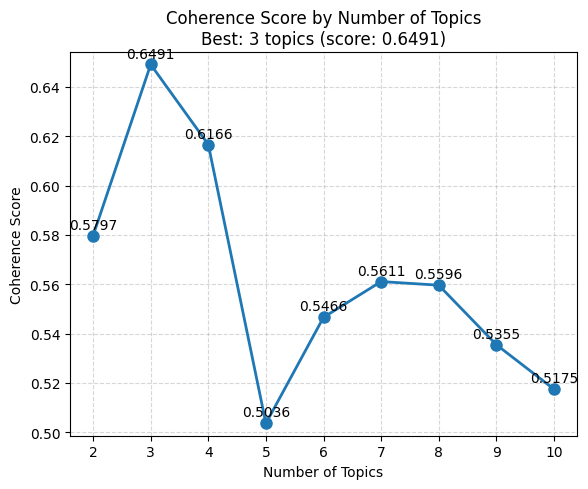

In [18]:
plt.figure(figsize=(6, 5))
plt.plot(topic_range, coherence_values, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")

# margin atas agar label muat
plt.ylim(min(coherence_values) - 0.005, max(coherence_values) + 0.005)

plt.title(
    f"Coherence Score by Number of Topics\n"
    f"Best: {topic_range[best_idx]} topics (score: {coherence_values[best_idx]:.4f})"
)

plt.xticks(topic_range)
plt.grid(True, linestyle='--', alpha=0.5)

# Tambahkan label skor di atas titik
for i, score in enumerate(coherence_values):
    plt.annotate(
        f'{score:.4f}',
        (topic_range[i], score),
        textcoords="offset points",
        xytext=(0,5),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [19]:
# Temukan jumlah topik terbaik
best_idx = coherence_values.index(max(coherence_values))
best_topic_num = topic_range[best_idx]
best_coherence = coherence_values[best_idx]
best_model = model_list[best_idx]

print(f"Jumlah topik terbaik: {best_topic_num}")
print(f"Coherence score terbaik: {best_coherence:.4f}")

Jumlah topik terbaik: 3
Coherence score terbaik: 0.6491


### 4.3 Visualisasi dengan pyLDAvis

In [20]:
vis = gensimvis.prepare(best_model, corpus, dictionary)
pyLDAvis.display(vis)

In [21]:
# Menampilkan topik terbaik
print(f"Topik-topik dari model terbaik ({best_topic_num} topik):")
topics = best_model.print_topics(num_words=20)
for idx, topic in topics:
    print(f"Topik {idx + 1}:")
    print(f"{topic}")
    print()

Topik-topik dari model terbaik (3 topik):
Topik 1:
0.140*"aplikasi" + 0.064*"terus" + 0.056*"tidak bisa" + 0.042*"mau" + 0.041*"eror" + 0.037*"buka" + 0.037*"sering" + 0.021*"susah" + 0.018*"jadi" + 0.018*"login" + 0.016*"ganggu" + 0.015*"masuk" + 0.015*"server" + 0.014*"masalah" + 0.013*"selalu" + 0.010*"baik" + 0.010*"salah" + 0.010*"sendiri" + 0.009*"kendala" + 0.008*"update"

Topik 2:
0.049*"jaring" + 0.044*"sekali" + 0.042*"byu" + 0.041*"sinyal" + 0.024*"bagus" + 0.022*"kartu" + 0.022*"baik" + 0.022*"lambat" + 0.020*"sangat" + 0.020*"hilang" + 0.020*"buat" + 0.018*"pakai" + 0.018*"makin" + 0.017*"jelek" + 0.013*"kalau" + 0.013*"lebih" + 0.013*"murah" + 0.012*"sama" + 0.011*"banyak" + 0.011*"parah"

Topik 3:
0.051*"beli" + 0.051*"kuota" + 0.039*"paket" + 0.026*"pulsa" + 0.019*"padahal" + 0.019*"isi" + 0.018*"tidak ada" + 0.018*"data" + 0.017*"gb" + 0.016*"byu" + 0.016*"baru" + 0.015*"kali" + 0.015*"hari" + 0.014*"pakai" + 0.012*"tidak masuk" + 0.012*"aku" + 0.011*"bayar" + 0.010*"j

### 4.4 Hasil Interpertasi Manual:
1. Topik 1: Aspek Aplikasi
2. Topik 2: Aspek Jaringan
3. Topik 3: Aspek Pembelian

### 4.5 Menyiapkan file .csv untuk pelabelan manual

In [22]:
# MENGAMBIL KOLOM ULASAN NON PREPROCESSED
# Baca data
df = pd.read_csv('data/data_stemming.csv', converters={'ulasan': ast.literal_eval})
# Ambil kolom yang diperlukan
df_preprocessing = df[['content', 'stemming']].copy()
# Ubah nama kolom agar lebih deskriptif
df_preprocessing.columns = ['ulasan', 'ulasan_preprocessed']
# Tambahkan kolom baru dengan isi default (misalnya kosong atau NaN)
df_preprocessing['aplikasi'] = ''
df_preprocessing['jaringan'] = ''
df_preprocessing['pembelian'] = ''
# Simpan Hasil Preprocessing
df_preprocessing.to_csv('data/ulasan.csv', index=False)
# Tampilkan
df_preprocessing

,ulasan,ulasan_preprocessed,aplikasi,jaringan,pembelian
0,Aplikasi makin sering update makin sering eror...,"['aplikasi', 'makin', 'sering', 'update', 'mak...",,,
1,simpel aja memang terbaik kokk,"['sederhana', 'memang', 'baik', 'kokk']",,,
2,"harga harganya sangat terjangkau, bagus bangett","['harga', 'harga', 'sangat', 'jangkau', 'bagus...",,,
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","['kalau', 'jam', 'atas', 'susah', 'data', 'suk...",,,
4,mantap,['mantap'],,,
...,...,...,...,...,...
8170,"Untuk aplikasi udah bagus, tapi kenapa level s...","['aplikasi', 'bagus', 'level', 'justru', 'awal...",,,
8171,By U Menarik sekali,"['byu', 'tarik', 'sekali']",,,
8172,si paling jaringan telkom,"['paling', 'jaring', 'telkom']",,,
8173,"Jaringan kek apaaa, kog jelek bgt 😭","['jaring', 'apa', 'jelek', 'sekali']",,,


## SVM

### Memuat Data Berlabel & Persiapan Data untuk Model

In [23]:
# Memuat dataset yang sudah memiliki label aspek dan sentimen
df_labeled = pd.read_csv('ulasan_berlabel.csv')

# Menampilkan 5 baris pertama dari data asli untuk referensi
df_labeled.head()

,ulasan,ulasan_preprocessed,aplikasi,jaringan,pembelian
0,Aplikasi makin sering update makin sering eror...,"['aplikasi', 'makin', 'sering', 'baru', 'makin...",-1,0,0
1,simpel aja memang terbaik kokk,"['sederhana', 'memang', 'baik']",0,0,0
2,"harga harganya sangat terjangkau, bagus bangett","['harga', 'harga', 'sangat', 'jangkau', 'bagus...",0,0,1
3,"kalo udah jm 12 ke atas kox susah,data suka E ...","['kalau', 'jam', 'atas', 'sulit', 'data', 'suk...",0,-1,0
4,mantap,['mantap'],0,0,0


In [24]:
# Kolom-kolom aspek yang akan dianalisis
aspek_cols = ['aplikasi', 'jaringan', 'pembelian']

# Dictionary untuk menyimpan data 2 kelas (positif & negatif) untuk setiap aspek
data_per_aspek = {}

print("Memfilter data untuk setiap aspek (membuang kelas netral)...")
for aspek in aspek_cols:
    # Filter data untuk membuang kelas netral (0)
    df_aspek_filtered = df_labeled[df_labeled[aspek] != 0].copy()
    
    # Simpan fitur (X) dan target (y) yang sudah difilter
    data_per_aspek[aspek] = {
        'X': df_aspek_filtered['ulasan_preprocessed'],
        'y': df_aspek_filtered[aspek]
    }
    print(f"Aspek '{aspek}': {len(df_aspek_filtered)} data (positif/negatif)")

Memfilter data untuk setiap aspek (membuang kelas netral)...
Aspek 'aplikasi': 3308 data (positif/negatif)
Aspek 'jaringan': 3201 data (positif/negatif)
Aspek 'pembelian': 3035 data (positif/negatif)


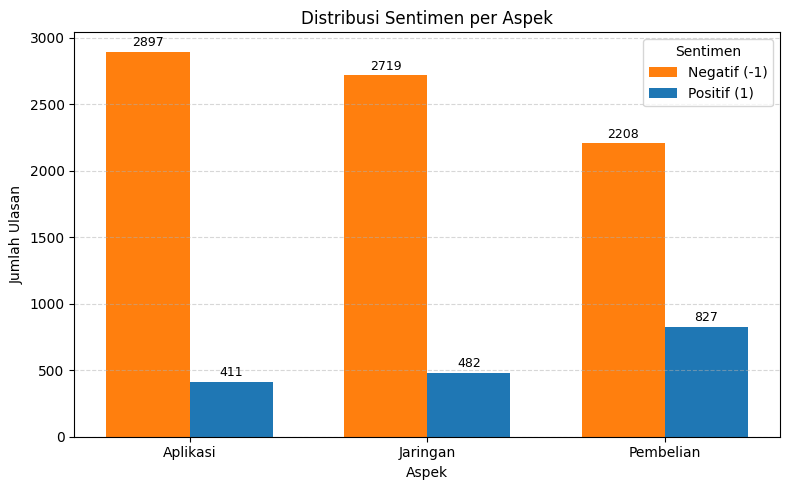

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil jumlah data untuk tiap sentimen di setiap aspek
labels = aspek_cols  # ['aplikasi', 'jaringan', 'pembelian']
negatif_counts = []
positif_counts = []

for aspek in aspek_cols:
    y = data_per_aspek[aspek]['y']
    counts = y.value_counts()
    negatif_counts.append(counts.get(-1, 0))
    positif_counts.append(counts.get(1, 0))

# Posisi X untuk masing-masing aspek
x = np.arange(len(labels))  # posisi untuk aspek
width = 0.35  # lebar bar

# Buat plot
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, negatif_counts, width, label='Negatif (-1)', color='tab:orange')
bars2 = ax.bar(x + width/2, positif_counts, width, label='Positif (1)', color='tab:blue')

# Tambahkan teks di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 20, str(height),
                ha='center', va='bottom', fontsize=9)

# Tambahkan label dan judul
ax.set_ylabel('Jumlah Ulasan')
ax.set_xlabel('Aspek')
ax.set_title('Distribusi Sentimen per Aspek')
ax.set_xticks(x)
ax.set_xticklabels([label.capitalize() for label in labels])
ax.legend(title='Sentimen')

# Tambahkan grid horizontal
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Definisi Pipeline, Parameter Grid, dan Cross-Validation

In [26]:
# 1. Setup 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Setup Pipeline dengan TF-IDF, SMOTE, dan SVM
pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(random_state=42, probability=True))
])

# 3. Parameter Grid untuk Grid Search
param_grid = {
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.1, 1, 10]
}

print("Pipeline dan parameter grid siap digunakan.")

Pipeline dan parameter grid siap digunakan.


### Menjalankan Grid Search untuk Setiap Aspek

In [27]:
# Dictionary untuk menyimpan hasil terbaik
best_params_per_aspek = {}
best_scores_per_aspek = {}
best_estimators_per_aspek = {}
cv_results_per_aspek = {}

for aspek in aspek_cols:
    print(f"\n{'='*60}\nMemulai Grid Search untuk Aspek: {aspek.upper()}\n{'='*60}")
    
    # Ambil data 2 kelas yang relevan
    X_aspek = data_per_aspek[aspek]['X']
    y_aspek = data_per_aspek[aspek]['y']
    
    grid_search = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=cv, 
        scoring='f1_macro',
        n_jobs=-1, 
        verbose=1
    )
    
    # Latih pada data 2 kelas
    grid_search.fit(X_aspek, y_aspek)
    
    # Simpan hasil terbaik
    best_params_per_aspek[aspek] = grid_search.best_params_
    best_scores_per_aspek[aspek] = grid_search.best_score_
    best_estimators_per_aspek[aspek] = grid_search.best_estimator_
    cv_results_per_aspek[aspek] = pd.DataFrame(grid_search.cv_results_)
    
    print(f"\nParameter terbaik untuk {aspek.upper()}: {grid_search.best_params_}")
    print(f"Skor F1-Macro CV terbaik: {grid_search.best_score_:.4f}")


Memulai Grid Search untuk Aspek: APLIKASI
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Parameter terbaik untuk APLIKASI: {'classifier__C': 0.1, 'classifier__kernel': 'linear'}
Skor F1-Macro CV terbaik: 0.8889

Memulai Grid Search untuk Aspek: JARINGAN
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Parameter terbaik untuk JARINGAN: {'classifier__C': 0.1, 'classifier__kernel': 'linear'}
Skor F1-Macro CV terbaik: 0.8682

Memulai Grid Search untuk Aspek: PEMBELIAN
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Parameter terbaik untuk PEMBELIAN: {'classifier__C': 10, 'classifier__kernel': 'rbf'}
Skor F1-Macro CV terbaik: 0.9124


### Confusion Matrix dan Laporan Klasifikasi

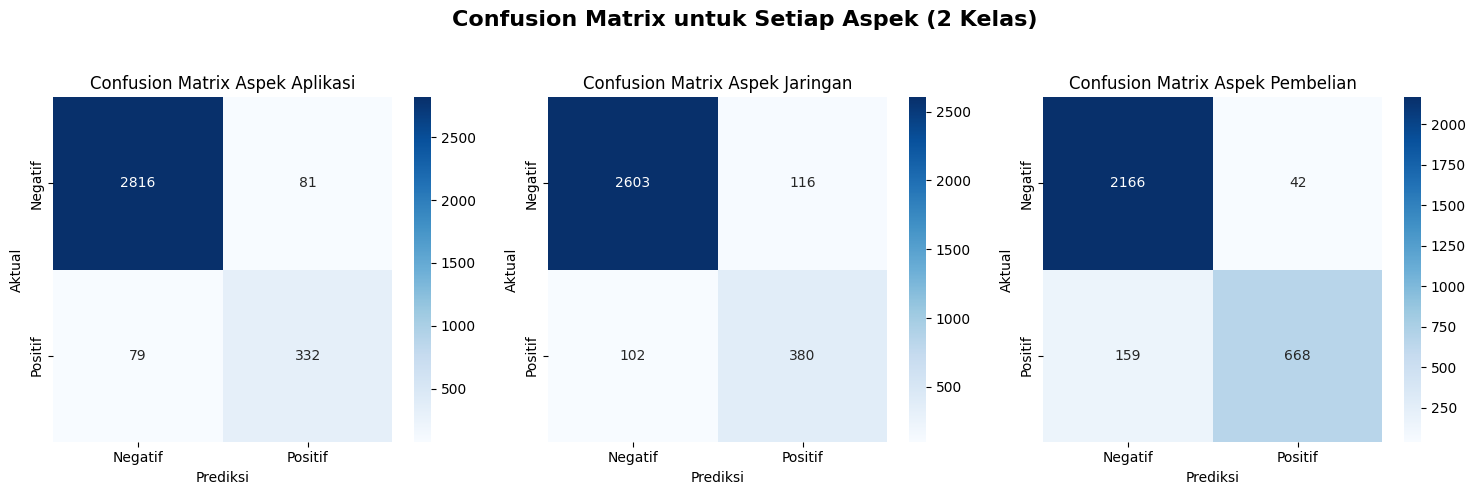


Laporan Klasifikasi untuk Aspek: APLIKASI
              precision    recall  f1-score   support

     Negatif       0.97      0.97      0.97      2897
     Positif       0.80      0.81      0.81       411

    accuracy                           0.95      3308
   macro avg       0.89      0.89      0.89      3308
weighted avg       0.95      0.95      0.95      3308


Laporan Klasifikasi untuk Aspek: JARINGAN
              precision    recall  f1-score   support

     Negatif       0.96      0.96      0.96      2719
     Positif       0.77      0.79      0.78       482

    accuracy                           0.93      3201
   macro avg       0.86      0.87      0.87      3201
weighted avg       0.93      0.93      0.93      3201


Laporan Klasifikasi untuk Aspek: PEMBELIAN
              precision    recall  f1-score   support

     Negatif       0.93      0.98      0.96      2208
     Positif       0.94      0.81      0.87       827

    accuracy                           0.93      303

In [28]:
# Membuat subplot untuk confusion matrix
fig, axes = plt.subplots(1, len(aspek_cols), figsize=(15, 5))
fig.suptitle('Confusion Matrix untuk Setiap Aspek (2 Kelas)', fontsize=16, fontweight='bold')

for i, aspek in enumerate(aspek_cols):
    # Ambil data 2 kelas
    X_aspek = data_per_aspek[aspek]['X']
    y_aspek = data_per_aspek[aspek]['y']

    # Dapatkan prediksi dari cross validation
    y_pred = cross_val_predict(
        best_estimators_per_aspek[aspek], 
        X_aspek, 
        y_aspek, 
        cv=cv,
        n_jobs=-1
    )
    
    # Buat confusion matrix dengan label baru [-1, 1]
    cm = confusion_matrix(y_aspek, y_pred, labels=[-1, 1])
    
    # Plot heatmap dengan label baru ['Negatif', 'Positif']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negatif', 'Positif'],
                yticklabels=['Negatif', 'Positif'])
    axes[i].set_title(f'Confusion Matrix Aspek {aspek.title()}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Tampilkan Classification Report untuk setiap aspek dengan target names baru
for aspek in aspek_cols:
    print(f"\n{'='*60}\nLaporan Klasifikasi untuk Aspek: {aspek.upper()}\n{'='*60}")
    
    # Prediksi ulang untuk laporan
    X_aspek = data_per_aspek[aspek]['X']
    y_aspek = data_per_aspek[aspek]['y']
    y_pred = cross_val_predict(
        best_estimators_per_aspek[aspek], 
        X_aspek, 
        y_aspek, 
        cv=cv,
        n_jobs=-1
    )
    
    # Gunakan target_names yang sudah diubah
    print(classification_report(y_aspek, y_pred, target_names=['Negatif', 'Positif']))

### Meyimpan Model

In [29]:
# Membuat direktori untuk menyimpan model jika belum ada
model_dir = 'model_terbaik_2_kelas'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Menyimpan setiap model terbaik
for aspek, model in best_estimators_per_aspek.items():
    file_path = os.path.join(model_dir, f'model_{aspek}.joblib')
    joblib.dump(model, file_path)
    print(f"Model untuk aspek '{aspek}' telah disimpan di: {file_path}")

Model untuk aspek 'aplikasi' telah disimpan di: model_terbaik_2_kelas\model_aplikasi.joblib
Model untuk aspek 'jaringan' telah disimpan di: model_terbaik_2_kelas\model_jaringan.joblib
Model untuk aspek 'pembelian' telah disimpan di: model_terbaik_2_kelas\model_pembelian.joblib


---

## RINCIAN HASIL

### Distribusi Data Latih dan Data Uji di setiap Fold

In [30]:
# Menganalisis distribusi data latih dan uji di setiap fold
split_details_list = []

for aspek in aspek_cols:
    X_aspek = data_per_aspek[aspek]['X']
    y_aspek = data_per_aspek[aspek]['y']
    
    fold_counter = 1
    for train_index, test_index in cv.split(X_aspek, y_aspek):
        # Ambil label untuk data latih dan uji
        y_train, y_test = y_aspek.iloc[train_index], y_aspek.iloc[test_index]
        
        # Hitung distribusi kelas
        train_counts = y_train.value_counts().sort_index()
        test_counts = y_test.value_counts().sort_index()
        
        # Simpan hasil
        split_details_list.append({
            'Aspek': aspek,
            'Fold': fold_counter,
            'Train Negatif': train_counts.get(-1, 0),
            'Train Positif': train_counts.get(1, 0),
            'Test Negatif': test_counts.get(-1, 0),
            'Test Positif': test_counts.get(1, 0),
        })
        fold_counter += 1

# Konversi ke DataFrame
df_split_details = pd.DataFrame(split_details_list)

print("Analisis distribusi data latih & uji per fold selesai.")

Analisis distribusi data latih & uji per fold selesai.



Distribusi Data Latih vs Uji untuk Aspek: APLIKASI


,Train Negatif,Train Positif,Test Negatif,Test Positif
Fold,,,,
1,2317,329,580,82
2,2317,329,580,82
3,2318,328,579,83
4,2318,329,579,82
5,2318,329,579,82


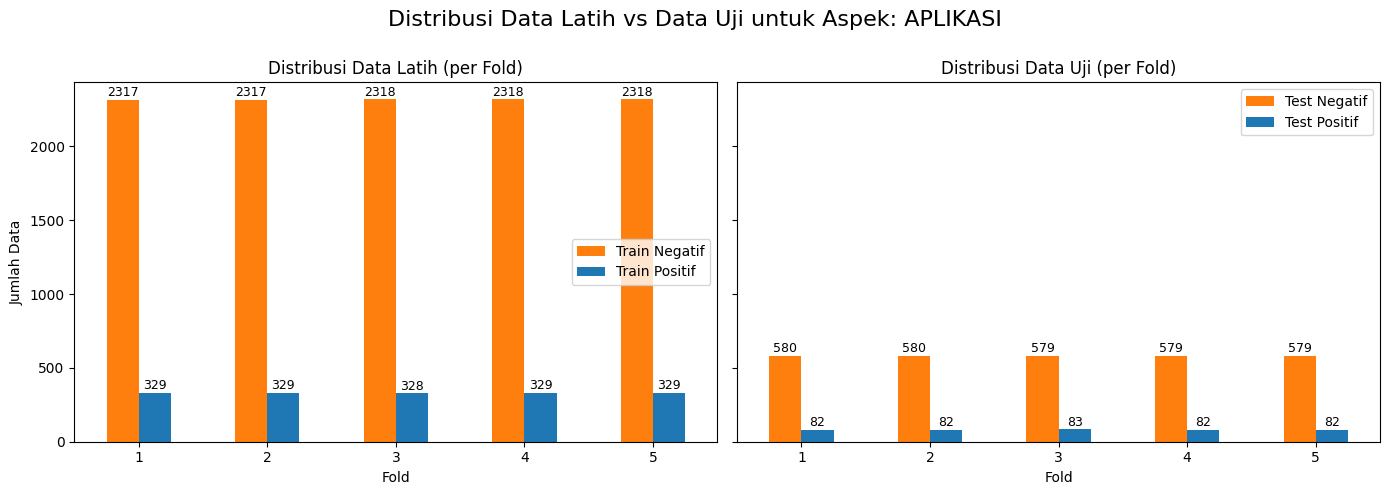


Distribusi Data Latih vs Uji untuk Aspek: JARINGAN


,Train Negatif,Train Positif,Test Negatif,Test Positif
Fold,,,,
1,2175,385,544,97
2,2175,386,544,96
3,2175,386,544,96
4,2175,386,544,96
5,2176,385,543,97


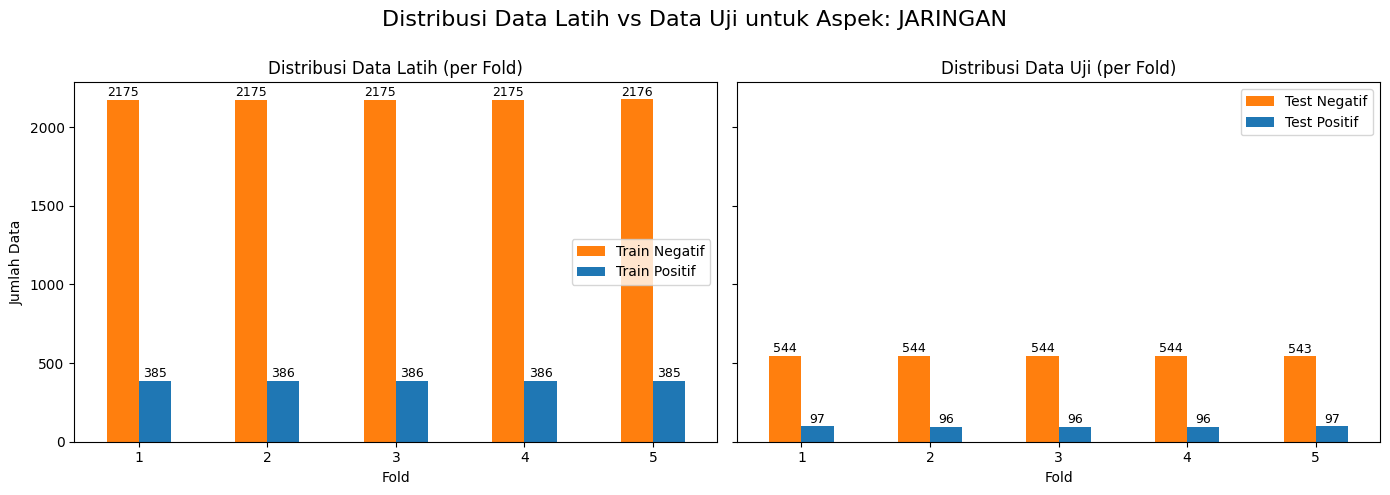


Distribusi Data Latih vs Uji untuk Aspek: PEMBELIAN


,Train Negatif,Train Positif,Test Negatif,Test Positif
Fold,,,,
1,1767,661,441,166
2,1767,661,441,166
3,1766,662,442,165
4,1766,662,442,165
5,1766,662,442,165


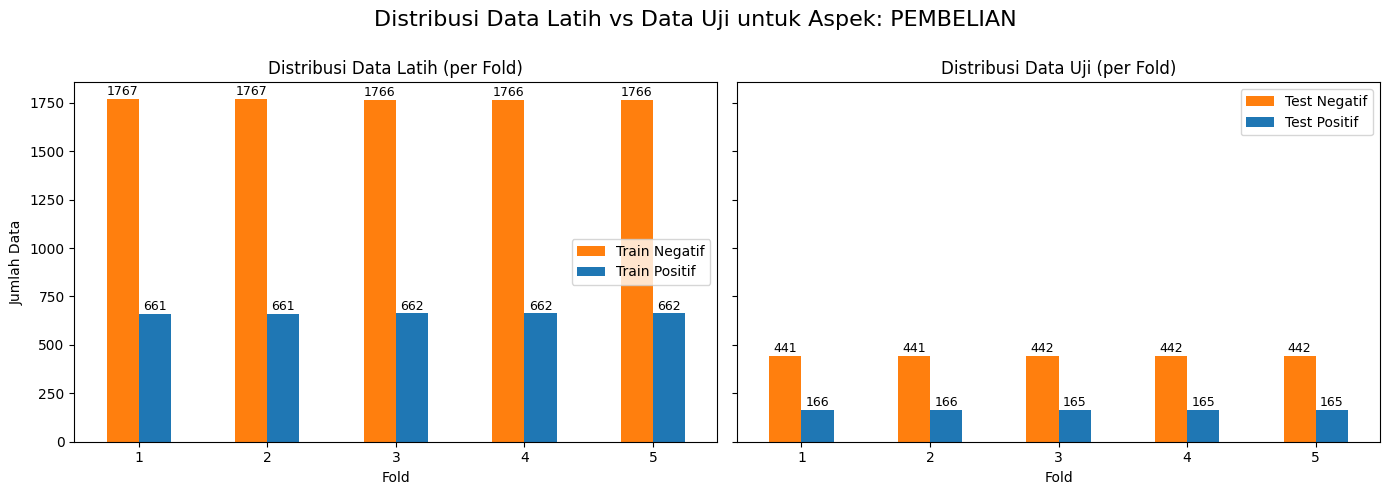

In [31]:
# Atur opsi tampilan pandas untuk format angka
pd.set_option('display.float_format', '{:.0f}'.format)

# Tampilkan tabel dan visualisasi untuk setiap aspek
for aspek in aspek_cols:
    print(f"\n{'='*70}\nDistribusi Data Latih vs Uji untuk Aspek: {aspek.upper()}\n{'='*70}")
    
    df_aspek_split = df_split_details[df_split_details['Aspek'] == aspek].drop('Aspek', axis=1)
    
    # Tampilkan Tabel
    display(df_aspek_split.set_index('Fold'))
    
    # Buat Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f'Distribusi Data Latih vs Data Uji untuk Aspek: {aspek.upper()}', fontsize=16)

    # --- Plot untuk Data Latih ---
    ax_train = axes[0]
    df_aspek_split.plot(
        x='Fold', 
        y=['Train Negatif', 'Train Positif'], 
        kind='bar', 
        ax=ax_train,
        color={'Train Negatif': 'tab:orange', 'Train Positif': 'tab:blue'},
        title='Distribusi Data Latih (per Fold)'
    )
    ax_train.set_ylabel('Jumlah Data')
    ax_train.tick_params(axis='x', rotation=0)

    # Tambahkan angka di atas bar latih
    for container in ax_train.containers:
        for bar in container:
            height = bar.get_height()
            ax_train.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{int(height)}',
                          ha='center', va='bottom', fontsize=9)

    # --- Plot untuk Data Uji ---
    ax_test = axes[1]
    df_aspek_split.plot(
        x='Fold', 
        y=['Test Negatif', 'Test Positif'], 
        kind='bar', 
        ax=ax_test,
        color={'Test Negatif': 'tab:orange', 'Test Positif': 'tab:blue'},
        title='Distribusi Data Uji (per Fold)'
    )
    ax_test.tick_params(axis='x', rotation=0)

    # Tambahkan angka di atas bar uji
    for container in ax_test.containers:
        for bar in container:
            height = bar.get_height()
            ax_test.text(bar.get_x() + bar.get_width() / 2, height + 5, f'{int(height)}',
                         ha='center', va='bottom', fontsize=9)

    # Rapikan layout
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# Reset opsi tampilan
pd.reset_option('display.float_format')


### Rincian Distribusi Kelas Sebelum dan Sesudah SMOTE pada Data Latih (Per Fold)

In [32]:
# Menganalisis distribusi data latih di setiap fold, sebelum dan sesudah SMOTE
smote_distribution_details = []

for aspek in aspek_cols:
    X_aspek = data_per_aspek[aspek]['X']
    y_aspek = data_per_aspek[aspek]['y']
    
    # Inisialisasi TF-IDF dan SMOTE di dalam loop untuk memastikan tidak ada data leakage
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    smote = SMOTE(random_state=42)
    
    fold_counter = 1
    for train_index, _ in cv.split(X_aspek, y_aspek):
        # Ambil data latih untuk fold saat ini
        X_train, y_train = X_aspek.iloc[train_index], y_aspek.iloc[train_index]
        
        # Hitung distribusi sebelum SMOTE
        before_counts = y_train.value_counts().sort_index()
        
        # Terapkan TF-IDF dan SMOTE
        X_train_tfidf = tfidf.fit_transform(X_train)
        _, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)
        
        # Hitung distribusi setelah SMOTE
        after_counts = pd.Series(y_train_smote).value_counts().sort_index()
        
        # Simpan hasil
        smote_distribution_details.append({
            'Aspek': aspek,
            'Fold': fold_counter,
            'Negatif (Sebelum)': before_counts.get(-1, 0),
            'Positif (Sebelum)': before_counts.get(1, 0),
            'Negatif (Sesudah)': after_counts.get(-1, 0),
            'Positif (Sesudah)': after_counts.get(1, 0),
        })
        fold_counter += 1

# Konversi ke DataFrame untuk tampilan yang lebih baik
df_smote_details = pd.DataFrame(smote_distribution_details)
print("Analisis distribusi per fold selesai.")

# Menampilkan tabel hasil analisis distribusi
display(df_smote_details)

Analisis distribusi per fold selesai.


,Aspek,Fold,Negatif (Sebelum),Positif (Sebelum),Negatif (Sesudah),Positif (Sesudah)
0,aplikasi,1,2317,329,2317,2317
1,aplikasi,2,2317,329,2317,2317
2,aplikasi,3,2318,328,2318,2318
3,aplikasi,4,2318,329,2318,2318
4,aplikasi,5,2318,329,2318,2318
5,jaringan,1,2175,385,2175,2175
6,jaringan,2,2175,386,2175,2175
7,jaringan,3,2175,386,2175,2175
8,jaringan,4,2175,386,2175,2175
9,jaringan,5,2176,385,2176,2176


Membuat visualisasi distribusi SMOTE untuk setiap fold...


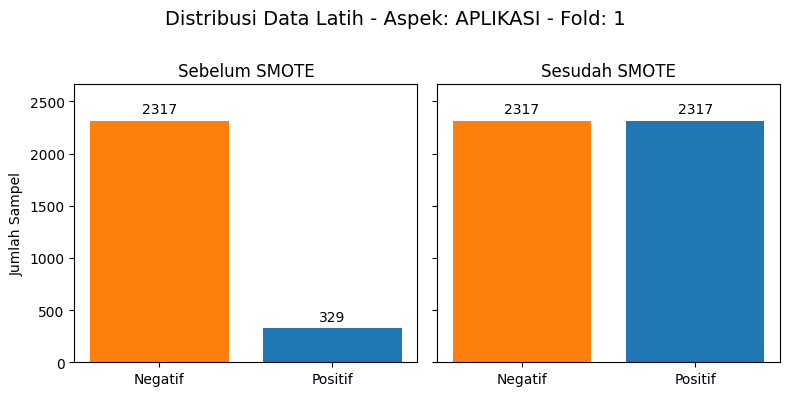

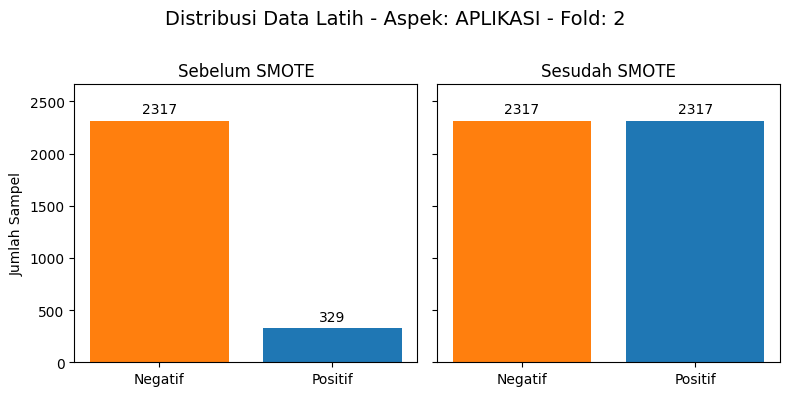

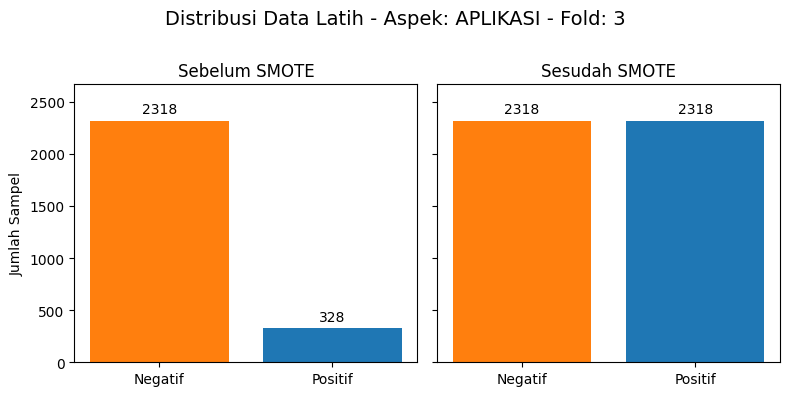

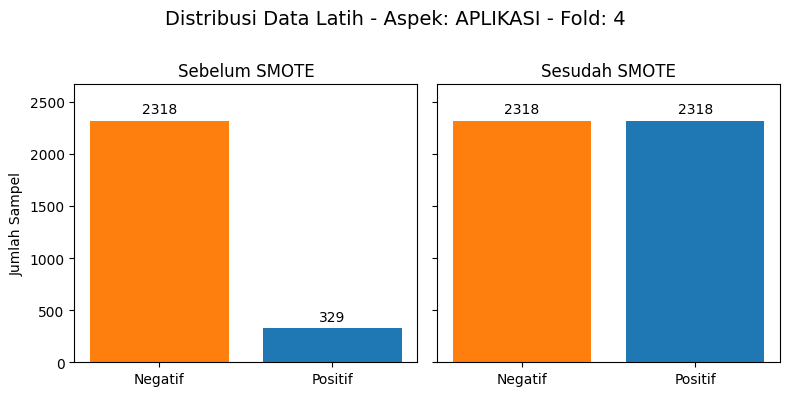

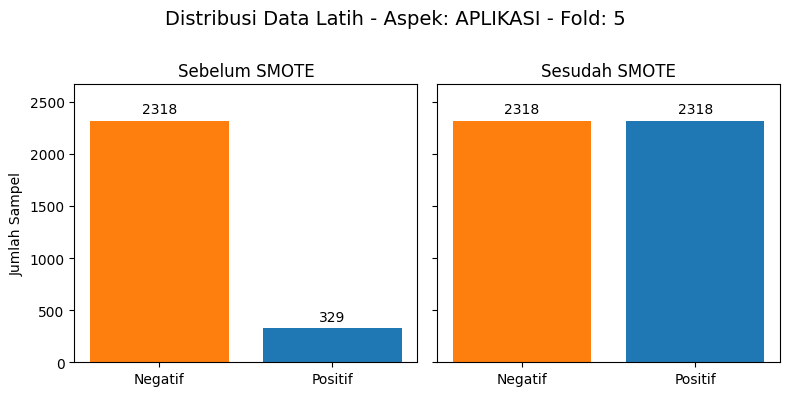

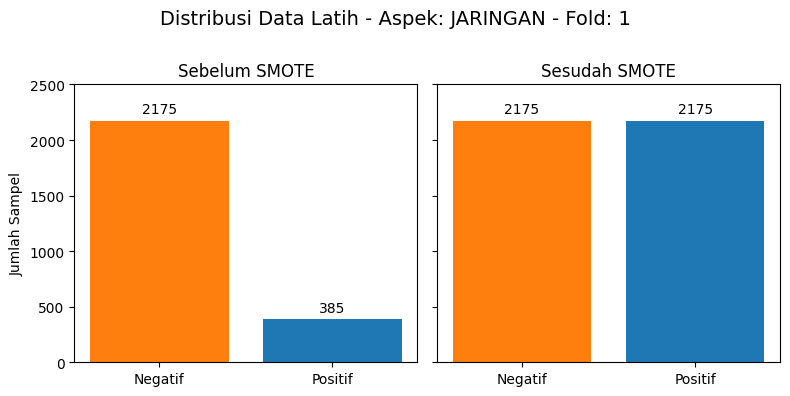

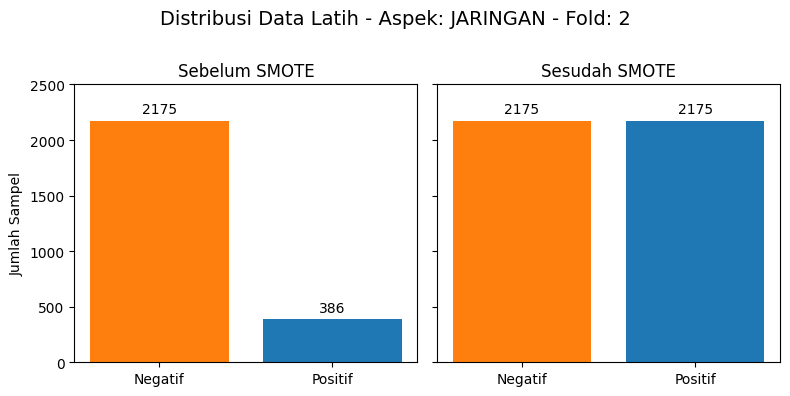

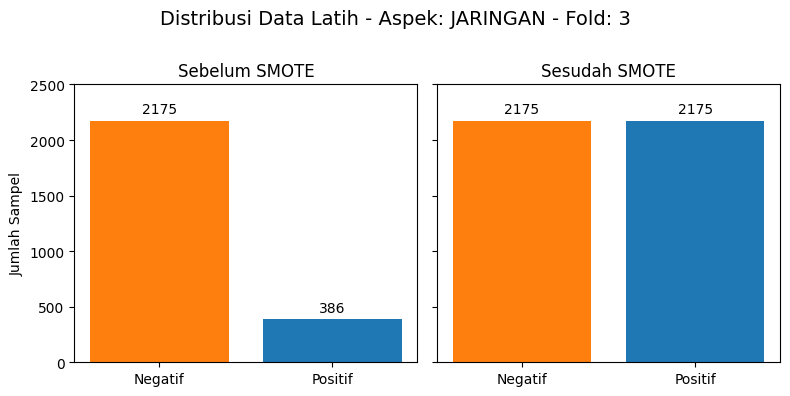

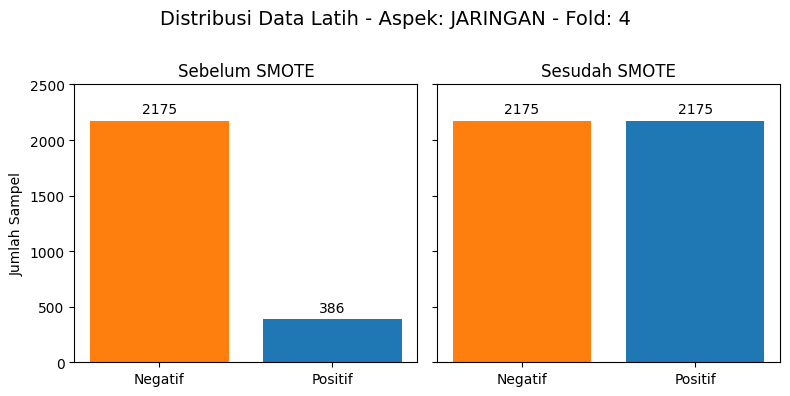

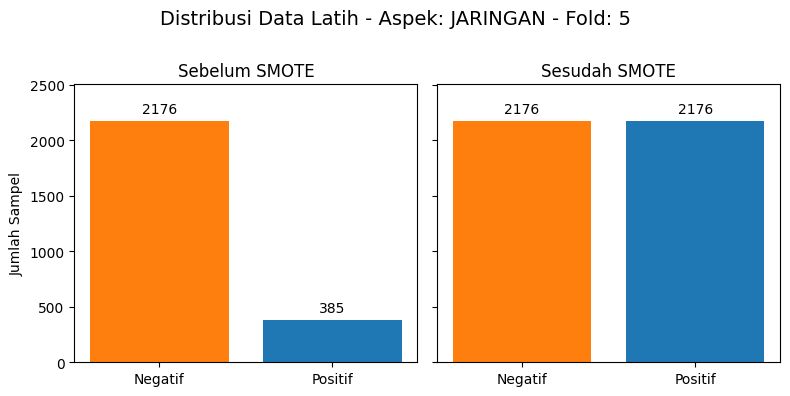

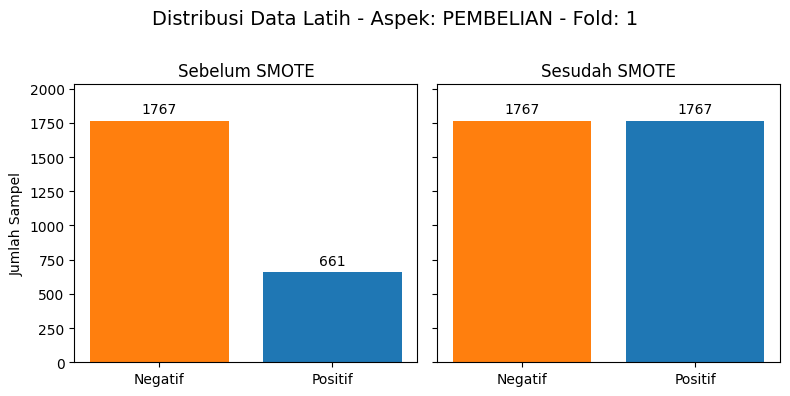

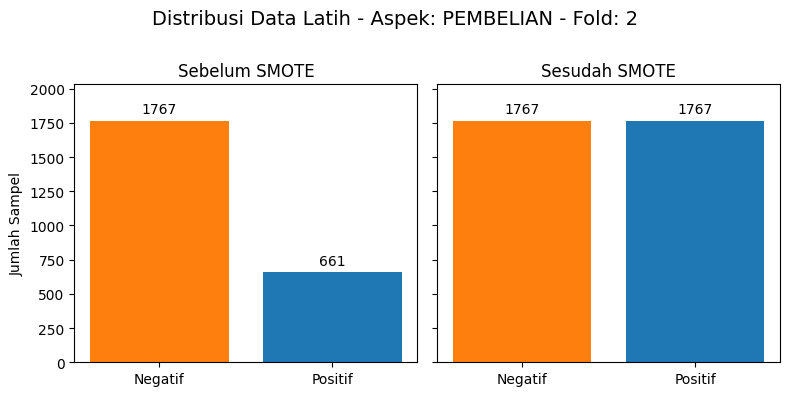

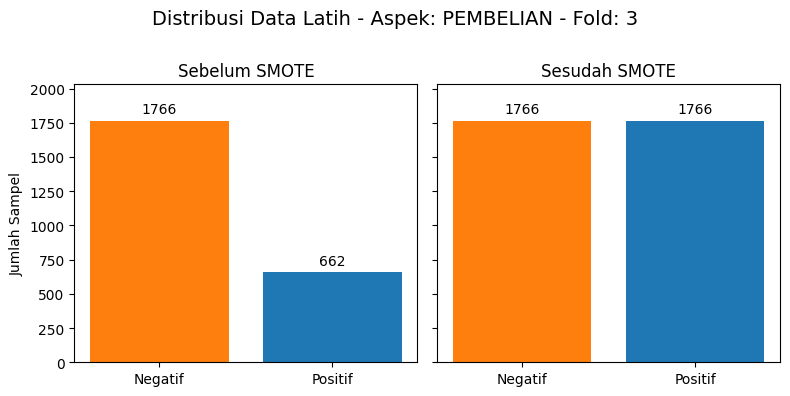

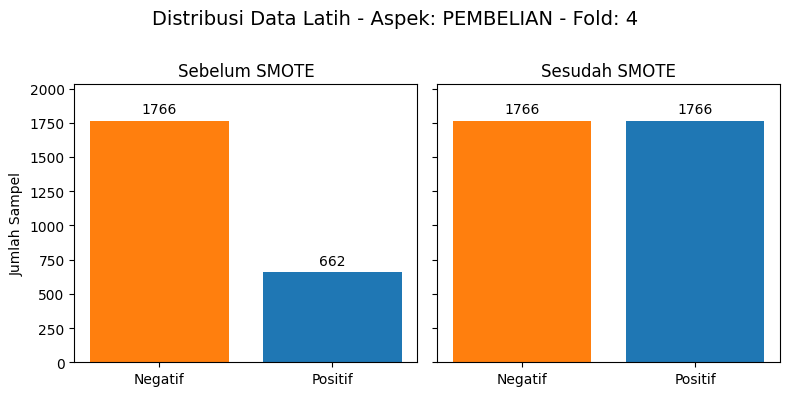

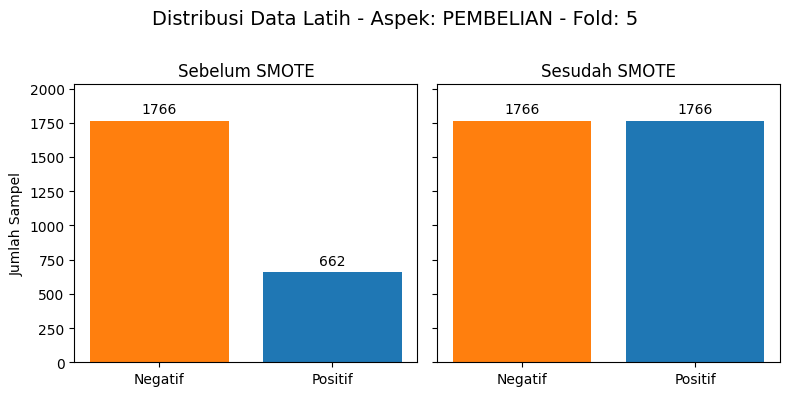

Selesai.


In [33]:
# Fungsi untuk menambahkan label angka di atas bar
def add_value_labels(ax):
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Iterasi setiap baris di DataFrame df_smote_details untuk membuat plot per fold
print("Membuat visualisasi distribusi SMOTE untuk setiap fold...")
for index, row in df_smote_details.iterrows():
    aspek = row['Aspek']
    fold = row['Fold']
    
    # Menyiapkan data untuk plot
    before_data = {'Negatif': row['Negatif (Sebelum)'], 'Positif': row['Positif (Sebelum)']}
    after_data = {'Negatif': row['Negatif (Sesudah)'], 'Positif': row['Positif (Sesudah)']}
    
    # Membuat 1 baris, 2 kolom subplot
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
    fig.suptitle(f'Distribusi Data Latih - Aspek: {aspek.upper()} - Fold: {fold}', fontsize=14)
    
    # === Plot untuk "Sebelum SMOTE" ===
    bars_before = axes[0].bar(before_data.keys(), before_data.values(), color=['tab:orange', 'tab:blue'])
    axes[0].set_title('Sebelum SMOTE')
    axes[0].set_ylabel('Jumlah Sampel')
    add_value_labels(axes[0]) # Menambahkan label angka
    
    # === Plot untuk "Sesudah SMOTE" ===
    bars_after = axes[1].bar(after_data.keys(), after_data.values(), color=['tab:orange', 'tab:blue'])
    axes[1].set_title('Sesudah SMOTE')
    add_value_labels(axes[1]) # Menambahkan label angka

    # Atur batas y agar ada ruang untuk label
    max_y = max(max(before_data.values()), max(after_data.values()))
    axes[0].set_ylim(0, max_y * 1.15)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97]) # Beri ruang untuk suptitle
    plt.show()

print("Selesai.")

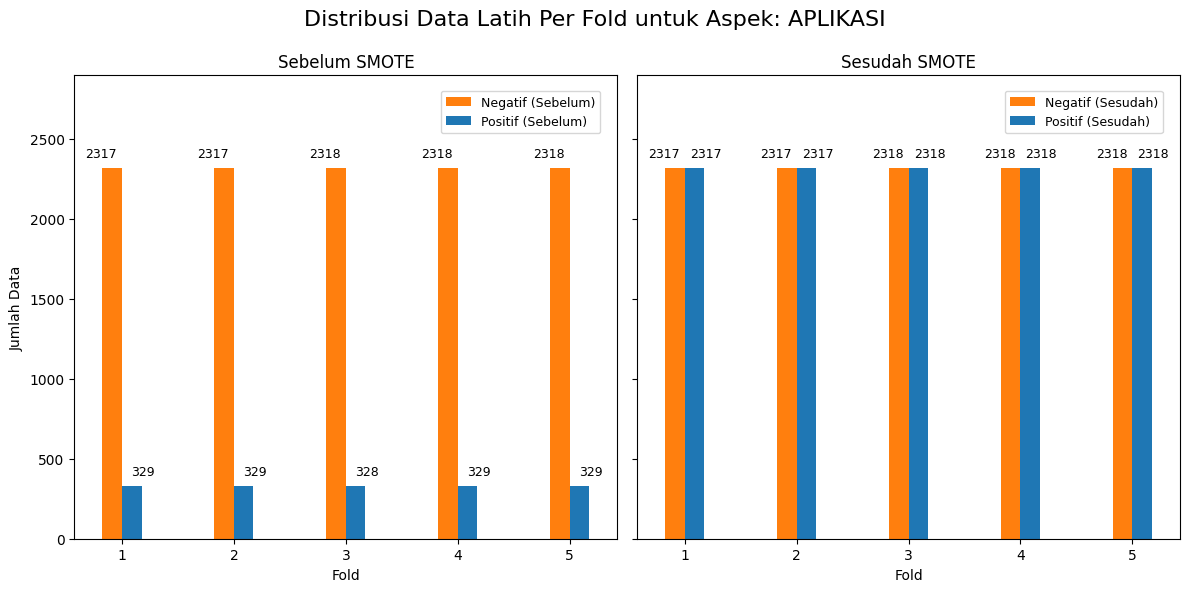

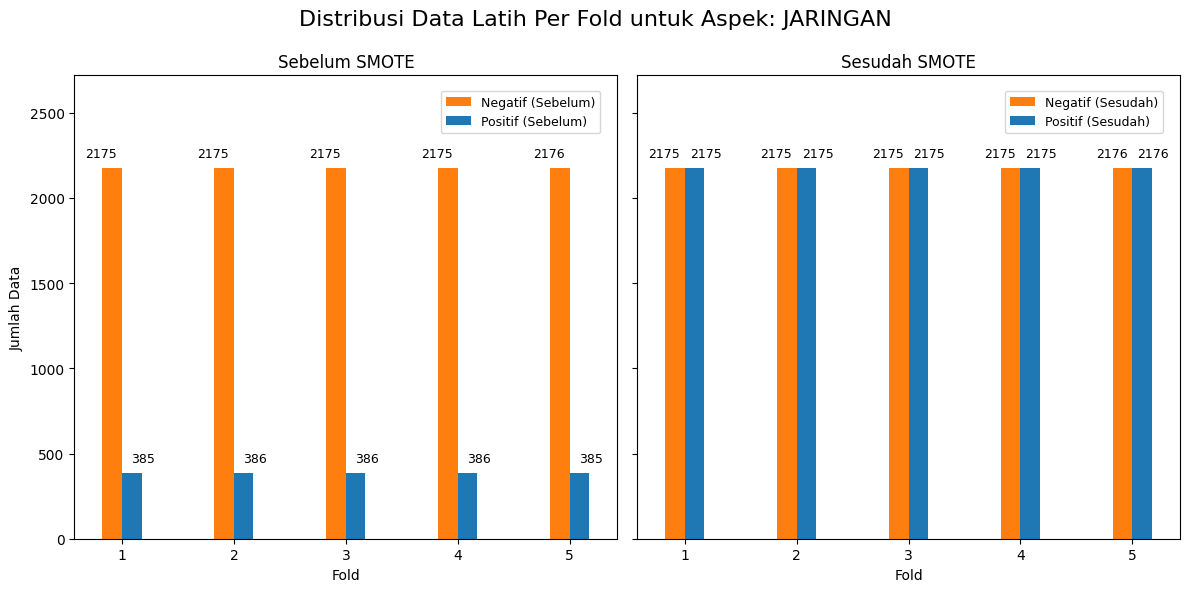

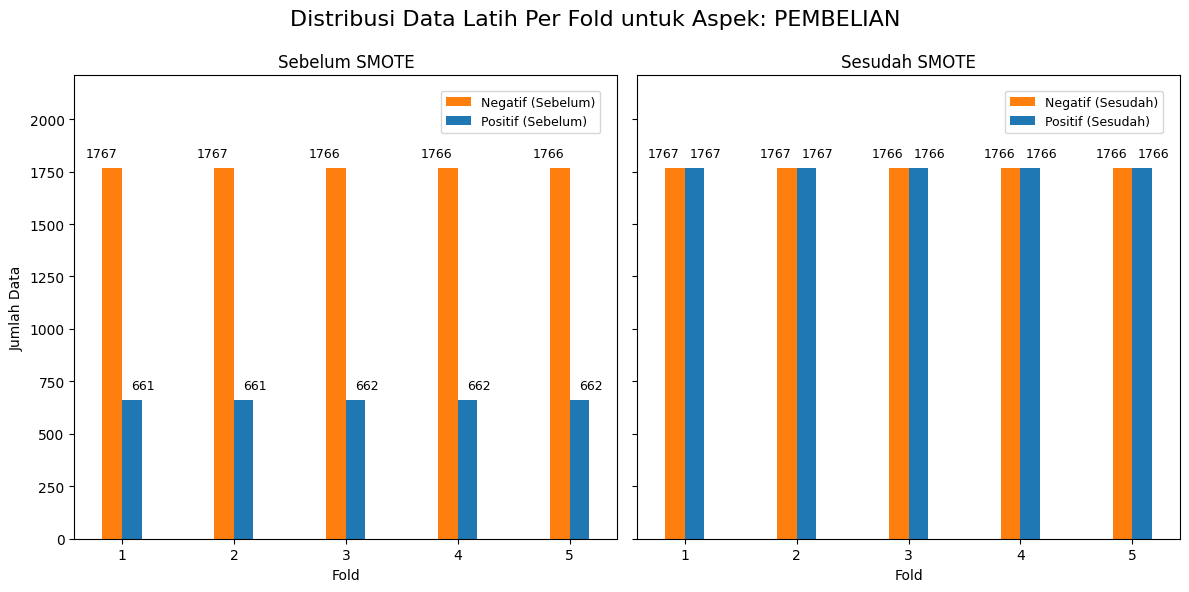

In [34]:
for aspek in aspek_cols:
    df_aspek_dist = df_smote_details[df_smote_details['Aspek'] == aspek]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    fig.suptitle(f'Distribusi Data Latih Per Fold untuk Aspek: {aspek.upper()}', fontsize=16)

    warna_sebelum = {'Negatif (Sebelum)': 'tab:orange', 'Positif (Sebelum)': 'tab:blue'}
    warna_sesudah = {'Negatif (Sesudah)': 'tab:orange', 'Positif (Sesudah)': 'tab:blue'}

    # Sebelum SMOTE
    df_aspek_dist.plot(
        x='Fold',
        y=['Negatif (Sebelum)', 'Positif (Sebelum)'],
        kind='bar',
        ax=axes[0],
        color=warna_sebelum,
        legend=False,
        width=0.35
    )
    axes[0].set_title('Sebelum SMOTE')
    axes[0].set_ylabel('Jumlah Data')
    axes[0].tick_params(axis='x', rotation=0)

    max_y_before = df_aspek_dist[['Negatif (Sebelum)', 'Positif (Sebelum)']].values.max()
    axes[0].set_ylim(0, max_y_before * 1.25)  # Tambah ruang atas supaya legenda dan label tidak menabrak

    # Letakkan legenda di dalam kotak, pojok kanan atas dengan padding
    axes[0].legend(warna_sebelum,
                   loc='upper right',
                   bbox_to_anchor=(0.98, 0.98),
                   fontsize=9,
                   frameon=True)

    # Anotasi angka
    for i, bar_group in enumerate(axes[0].containers):
        offset_x = -8 if i == 0 else 8
        for rect in bar_group:
            height = rect.get_height()
            axes[0].annotate(f'{int(height)}',
                             xy=(rect.get_x() + rect.get_width() / 2, height),
                             xytext=(offset_x, 6),
                             textcoords='offset points',
                             ha='center', va='bottom', fontsize=9)

    # Sesudah SMOTE
    df_aspek_dist.plot(
        x='Fold',
        y=['Negatif (Sesudah)', 'Positif (Sesudah)'],
        kind='bar',
        ax=axes[1],
        color=warna_sesudah,
        legend=False,
        width=0.35
    )
    axes[1].set_title('Sesudah SMOTE')
    axes[1].tick_params(axis='x', rotation=0)

    max_y_after = df_aspek_dist[['Negatif (Sesudah)', 'Positif (Sesudah)']].values.max()
    axes[1].set_ylim(0, max_y_after * 1.25)

    axes[1].legend(warna_sesudah,
                   loc='upper right',
                   bbox_to_anchor=(0.98, 0.98),
                   fontsize=9,
                   frameon=True)

    for i, bar_group in enumerate(axes[1].containers):
        offset_x = -8 if i == 0 else 8
        for rect in bar_group:
            height = rect.get_height()
            axes[1].annotate(f'{int(height)}',
                             xy=(rect.get_x() + rect.get_width() / 2, height),
                             xytext=(offset_x, 6),
                             textcoords='offset points',
                             ha='center', va='bottom', fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

### Rincian Hasil Grid Search (Per Fold)

In [35]:
# List untuk menyimpan semua detail dari setiap kombinasi di setiap fold
grid_search_details_list_full = []

print("Mengekstrak hasil lengkap Grid Search untuk semua kombinasi...")
for aspek in aspek_cols:
    # Mengambil hasil CV yang sudah tersimpan
    results_df = cv_results_per_aspek[aspek]
    
    # Mengidentifikasi kolom parameter dan kolom skor per fold
    param_cols = [col for col in results_df.columns if col.startswith('param_')]
    split_cols = [col for col in results_df.columns if col.startswith('split') and '_test_score' in col]
    
    # Iterasi melalui setiap baris di hasil CV (setiap baris = 1 kombinasi hyperparameter)
    for index, row in results_df.iterrows():
        # Ekstrak nilai parameter untuk baris ini
        params = {p.replace('param_svc__', ''): row[p] for p in param_cols}
        
        # Iterasi melalui skor setiap fold untuk kombinasi parameter ini
        for i, split_col in enumerate(split_cols):
            if split_col in row: # Pastikan kolom split ada
                fold_data = {
                    'Aspek': aspek,
                    'Fold': i + 1,
                    **params,  # Gabungkan dict parameter (misal: {'C': 1, 'kernel': 'linear'})
                    'F1-Macro Score': row[split_col]
                }
                grid_search_details_list_full.append(fold_data)

# Buat DataFrame dari list yang sudah terisi penuh
df_grid_search_details_full = pd.DataFrame(grid_search_details_list_full)
print("Ekstraksi selesai.")

# --- Tampilkan Tabel Lengkap ---
# Atur opsi tampilan agar semua baris terlihat
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

for aspek in aspek_cols:
    print(f"\n{'='*80}\nTABEL LENGKAP HASIL GRID SEARCH UNTUK ASPEK: {aspek.upper()}\n{'='*80}")
    
    # Filter data untuk aspek saat ini
    df_display = df_grid_search_details_full[df_grid_search_details_full['Aspek'] == aspek].drop('Aspek', axis=1)
    
    # Urutkan berdasarkan Fold, lalu skor F1 tertinggi untuk kemudahan membaca
    df_display_sorted = df_display.sort_values(by=['Fold', 'F1-Macro Score'], ascending=[True, False])
    
    display(df_display_sorted)

# Kembalikan opsi tampilan ke default
pd.reset_option('display.max_rows')
pd.reset_option('display.float_format')

Mengekstrak hasil lengkap Grid Search untuk semua kombinasi...
Ekstraksi selesai.

TABEL LENGKAP HASIL GRID SEARCH UNTUK ASPEK: APLIKASI


,Fold,param_classifier__C,param_classifier__kernel,F1-Macro Score
0,1,0.1000,linear,0.9024
25,1,10.0000,rbf,0.8819
15,1,1.0000,rbf,0.8672
20,1,10.0000,linear,0.8636
10,1,1.0000,linear,0.8568
5,1,0.1000,rbf,0.7797
1,2,0.1000,linear,0.8635
11,2,1.0000,linear,0.8523
16,2,1.0000,rbf,0.8513
26,2,10.0000,rbf,0.8443



TABEL LENGKAP HASIL GRID SEARCH UNTUK ASPEK: JARINGAN


,Fold,param_classifier__C,param_classifier__kernel,F1-Macro Score
40,1,1.0000,linear,0.8811
30,1,0.1000,linear,0.8731
50,1,10.0000,linear,0.8652
55,1,10.0000,rbf,0.8412
45,1,1.0000,rbf,0.8229
35,1,0.1000,rbf,0.6942
31,2,0.1000,linear,0.8820
41,2,1.0000,linear,0.8815
51,2,10.0000,linear,0.8604
56,2,10.0000,rbf,0.8445



TABEL LENGKAP HASIL GRID SEARCH UNTUK ASPEK: PEMBELIAN


,Fold,param_classifier__C,param_classifier__kernel,F1-Macro Score
70,1,1.0000,linear,0.9293
75,1,1.0000,rbf,0.9287
85,1,10.0000,rbf,0.9273
60,1,0.1000,linear,0.9270
80,1,10.0000,linear,0.9203
65,1,0.1000,rbf,0.8140
86,2,10.0000,rbf,0.9177
71,2,1.0000,linear,0.9139
76,2,1.0000,rbf,0.9130
81,2,10.0000,linear,0.8977


### Rangkuman Grid Search Per Aspek

In [36]:
# Membuat rangkuman dari tabel Grid Search yang sangat rinci
print("Membuat rangkuman hasil Grid Search per aspek...")

# Kolom-kolom parameter yang akan digunakan untuk pengelompokan
param_cols = [col for col in df_grid_search_details_full.columns if col not in ['Aspek', 'Fold', 'F1-Macro Score']]

# Kelompokkan berdasarkan Aspek dan kombinasi parameter, lalu hitung rata-rata (mean) dan standar deviasi (std)
summary_grid_search = df_grid_search_details_full.groupby(['Aspek'] + param_cols)['F1-Macro Score'].agg(['mean', 'std']).reset_index()

# Ganti nama kolom agar lebih jelas
summary_grid_search.rename(columns={'mean': 'Rata-rata F1-Macro', 'std': 'StDev F1-Macro'}, inplace=True)

print("Rangkuman selesai.")

# --- Tampilkan Tabel Rangkuman per Aspek ---
pd.set_option('display.float_format', '{:.4f}'.format)

for aspek in aspek_cols:
    print(f"\n{'='*80}\nRANGKUMAN PERINGKAT GRID SEARCH UNTUK ASPEK: {aspek.upper()}\n{'='*80}")
    
    # Filter data untuk aspek saat ini
    df_summary_display = summary_grid_search[summary_grid_search['Aspek'] == aspek].drop('Aspek', axis=1)
    
    # Urutkan berdasarkan skor rata-rata tertinggi untuk melihat kombinasi terbaik di atas
    df_summary_sorted = df_summary_display.sort_values(by='Rata-rata F1-Macro', ascending=False)
    
    display(df_summary_sorted)

pd.reset_option('display.float_format')

Membuat rangkuman hasil Grid Search per aspek...
Rangkuman selesai.

RANGKUMAN PERINGKAT GRID SEARCH UNTUK ASPEK: APLIKASI


,param_classifier__C,param_classifier__kernel,Rata-rata F1-Macro,StDev F1-Macro
0,0.1000,linear,0.8889,0.0233
3,1.0000,rbf,0.8795,0.0221
5,10.0000,rbf,0.8785,0.0245
2,1.0000,linear,0.8778,0.0227
4,10.0000,linear,0.8700,0.0226
1,0.1000,rbf,0.7910,0.0170



RANGKUMAN PERINGKAT GRID SEARCH UNTUK ASPEK: JARINGAN


,param_classifier__C,param_classifier__kernel,Rata-rata F1-Macro,StDev F1-Macro
6,0.1000,linear,0.8682,0.0163
8,1.0000,linear,0.8660,0.0218
10,10.0000,linear,0.8493,0.0267
11,10.0000,rbf,0.8386,0.0212
9,1.0000,rbf,0.8232,0.0200
7,0.1000,rbf,0.7026,0.0256



RANGKUMAN PERINGKAT GRID SEARCH UNTUK ASPEK: PEMBELIAN


,param_classifier__C,param_classifier__kernel,Rata-rata F1-Macro,StDev F1-Macro
17,10.0000,rbf,0.9124,0.0153
14,1.0000,linear,0.9121,0.0170
15,1.0000,rbf,0.9083,0.0169
12,0.1000,linear,0.9059,0.0164
16,10.0000,linear,0.8981,0.0137
13,0.1000,rbf,0.8181,0.0170


### Confusion Matrix dan Classification Report Per Fold


ANALISIS RINCI PER FOLD UNTUK ASPEK: APLIKASI

--- Fold: 1 ---


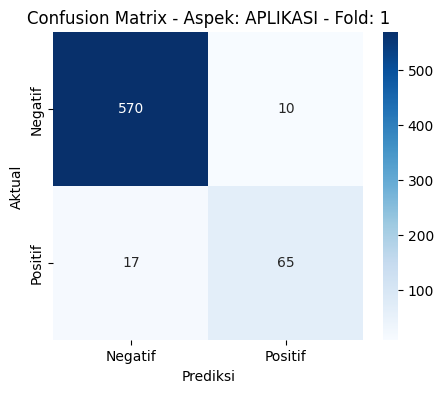


Classification Report - Aspek: APLIKASI - Fold: 1
              precision    recall  f1-score   support

     Negatif       0.97      0.98      0.98       580
     Positif       0.87      0.79      0.83        82

    accuracy                           0.96       662
   macro avg       0.92      0.89      0.90       662
weighted avg       0.96      0.96      0.96       662


--- Fold: 2 ---


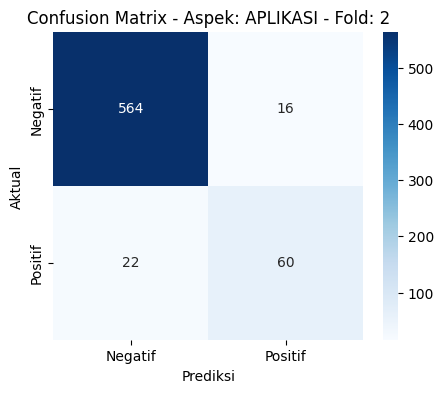


Classification Report - Aspek: APLIKASI - Fold: 2
              precision    recall  f1-score   support

     Negatif       0.96      0.97      0.97       580
     Positif       0.79      0.73      0.76        82

    accuracy                           0.94       662
   macro avg       0.88      0.85      0.86       662
weighted avg       0.94      0.94      0.94       662


--- Fold: 3 ---


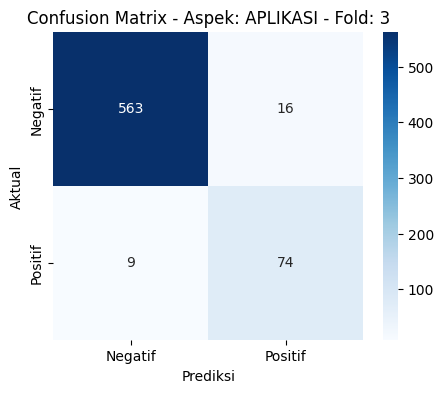


Classification Report - Aspek: APLIKASI - Fold: 3
              precision    recall  f1-score   support

     Negatif       0.98      0.97      0.98       579
     Positif       0.82      0.89      0.86        83

    accuracy                           0.96       662
   macro avg       0.90      0.93      0.92       662
weighted avg       0.96      0.96      0.96       662


--- Fold: 4 ---


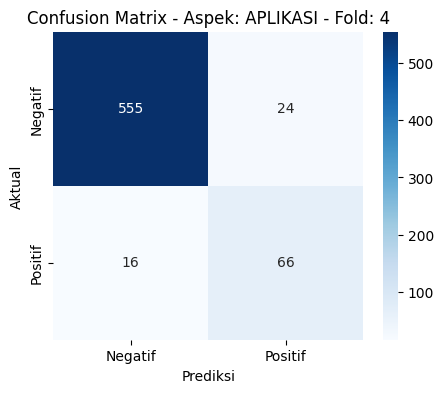


Classification Report - Aspek: APLIKASI - Fold: 4
              precision    recall  f1-score   support

     Negatif       0.97      0.96      0.97       579
     Positif       0.73      0.80      0.77        82

    accuracy                           0.94       661
   macro avg       0.85      0.88      0.87       661
weighted avg       0.94      0.94      0.94       661


--- Fold: 5 ---


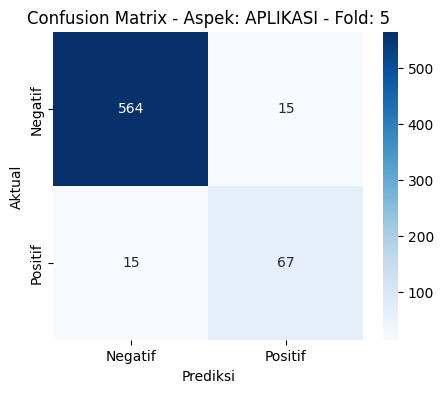


Classification Report - Aspek: APLIKASI - Fold: 5
              precision    recall  f1-score   support

     Negatif       0.97      0.97      0.97       579
     Positif       0.82      0.82      0.82        82

    accuracy                           0.95       661
   macro avg       0.90      0.90      0.90       661
weighted avg       0.95      0.95      0.95       661


ANALISIS RINCI PER FOLD UNTUK ASPEK: JARINGAN

--- Fold: 1 ---


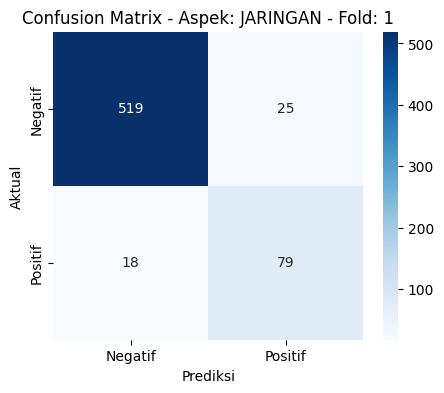


Classification Report - Aspek: JARINGAN - Fold: 1
              precision    recall  f1-score   support

     Negatif       0.97      0.95      0.96       544
     Positif       0.76      0.81      0.79        97

    accuracy                           0.93       641
   macro avg       0.86      0.88      0.87       641
weighted avg       0.94      0.93      0.93       641


--- Fold: 2 ---


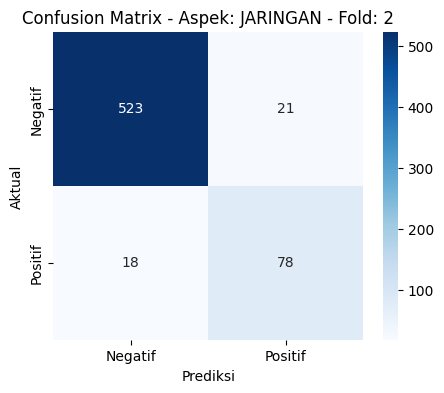


Classification Report - Aspek: JARINGAN - Fold: 2
              precision    recall  f1-score   support

     Negatif       0.97      0.96      0.96       544
     Positif       0.79      0.81      0.80        96

    accuracy                           0.94       640
   macro avg       0.88      0.89      0.88       640
weighted avg       0.94      0.94      0.94       640


--- Fold: 3 ---


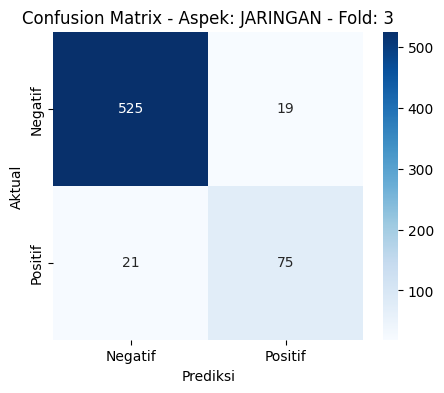


Classification Report - Aspek: JARINGAN - Fold: 3
              precision    recall  f1-score   support

     Negatif       0.96      0.97      0.96       544
     Positif       0.80      0.78      0.79        96

    accuracy                           0.94       640
   macro avg       0.88      0.87      0.88       640
weighted avg       0.94      0.94      0.94       640


--- Fold: 4 ---


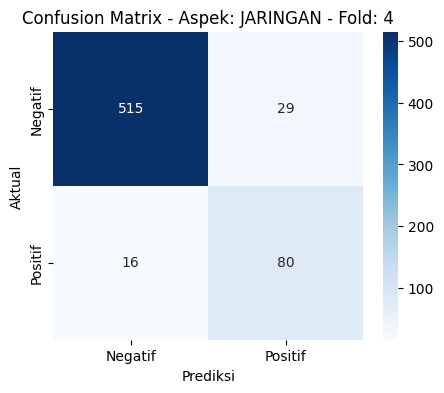


Classification Report - Aspek: JARINGAN - Fold: 4
              precision    recall  f1-score   support

     Negatif       0.97      0.95      0.96       544
     Positif       0.73      0.83      0.78        96

    accuracy                           0.93       640
   macro avg       0.85      0.89      0.87       640
weighted avg       0.93      0.93      0.93       640


--- Fold: 5 ---


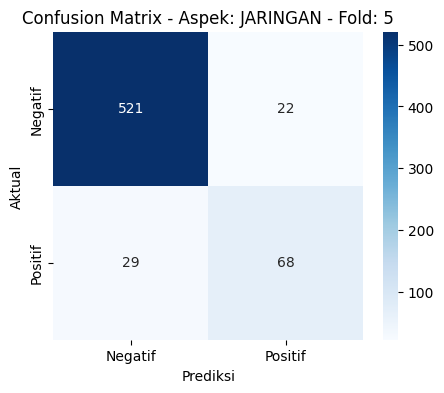


Classification Report - Aspek: JARINGAN - Fold: 5
              precision    recall  f1-score   support

     Negatif       0.95      0.96      0.95       543
     Positif       0.76      0.70      0.73        97

    accuracy                           0.92       640
   macro avg       0.85      0.83      0.84       640
weighted avg       0.92      0.92      0.92       640


ANALISIS RINCI PER FOLD UNTUK ASPEK: PEMBELIAN

--- Fold: 1 ---


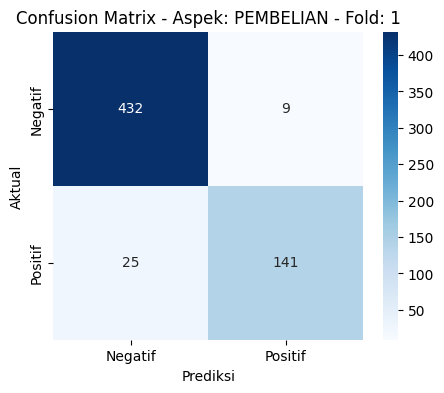


Classification Report - Aspek: PEMBELIAN - Fold: 1
              precision    recall  f1-score   support

     Negatif       0.95      0.98      0.96       441
     Positif       0.94      0.85      0.89       166

    accuracy                           0.94       607
   macro avg       0.94      0.91      0.93       607
weighted avg       0.94      0.94      0.94       607


--- Fold: 2 ---


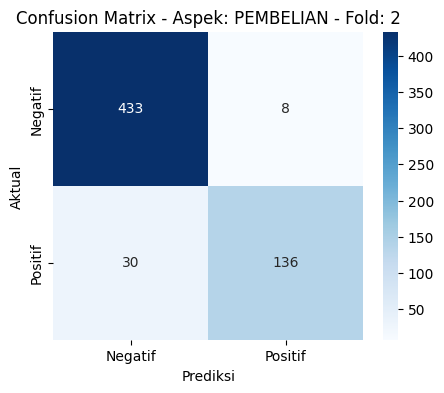


Classification Report - Aspek: PEMBELIAN - Fold: 2
              precision    recall  f1-score   support

     Negatif       0.94      0.98      0.96       441
     Positif       0.94      0.82      0.88       166

    accuracy                           0.94       607
   macro avg       0.94      0.90      0.92       607
weighted avg       0.94      0.94      0.94       607


--- Fold: 3 ---


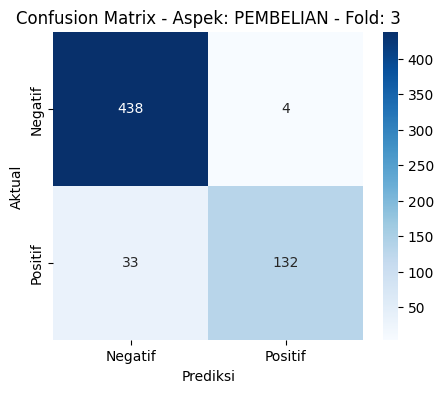


Classification Report - Aspek: PEMBELIAN - Fold: 3
              precision    recall  f1-score   support

     Negatif       0.93      0.99      0.96       442
     Positif       0.97      0.80      0.88       165

    accuracy                           0.94       607
   macro avg       0.95      0.90      0.92       607
weighted avg       0.94      0.94      0.94       607


--- Fold: 4 ---


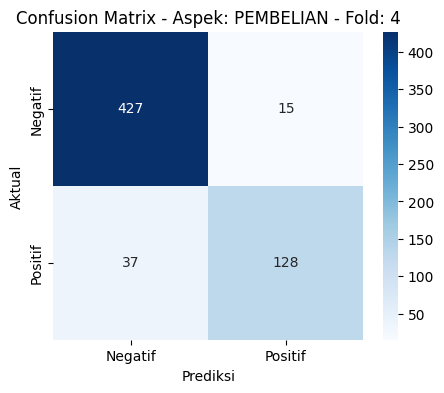


Classification Report - Aspek: PEMBELIAN - Fold: 4
              precision    recall  f1-score   support

     Negatif       0.92      0.97      0.94       442
     Positif       0.90      0.78      0.83       165

    accuracy                           0.91       607
   macro avg       0.91      0.87      0.89       607
weighted avg       0.91      0.91      0.91       607


--- Fold: 5 ---


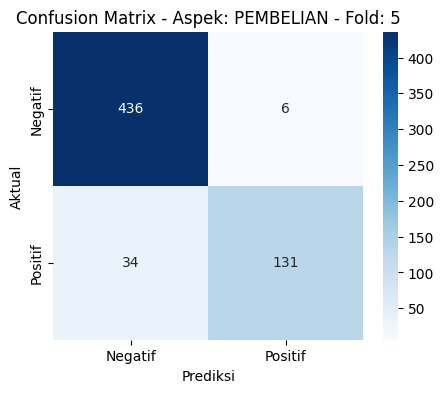


Classification Report - Aspek: PEMBELIAN - Fold: 5
              precision    recall  f1-score   support

     Negatif       0.93      0.99      0.96       442
     Positif       0.96      0.79      0.87       165

    accuracy                           0.93       607
   macro avg       0.94      0.89      0.91       607
weighted avg       0.94      0.93      0.93       607



Analisis rinci per fold selesai.


In [37]:
# List untuk menyimpan metrik dari setiap fold untuk tabel ringkasan
evaluation_details_list = []

# Iterasi untuk setiap aspek
for aspek in aspek_cols:
    print(f"\n{'='*80}\nANALISIS RINCI PER FOLD UNTUK ASPEK: {aspek.upper()}\n{'='*80}")
    
    # Ambil data dan model yang relevan
    X_aspek = data_per_aspek[aspek]['X']
    y_aspek = data_per_aspek[aspek]['y']
    best_model = best_estimators_per_aspek[aspek]
    
    fold_counter = 1
    # Iterasi untuk setiap fold dalam cross-validation
    for train_index, test_index in cv.split(X_aspek, y_aspek):
        print(f"\n--- Fold: {fold_counter} ---")
        
        # 1. Split data untuk fold saat ini
        X_train, X_test = X_aspek.iloc[train_index], X_aspek.iloc[test_index]
        y_train, y_test = y_aspek.iloc[train_index], y_aspek.iloc[test_index]
        
        # 2. Latih model pada data latih
        best_model.fit(X_train, y_train)
        
        # 3. Prediksi pada data uji
        y_pred = best_model.predict(X_test)
        
        # 4. Tampilkan Confusion Matrix
        cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Negatif', 'Positif'], 
                    yticklabels=['Negatif', 'Positif'])
        plt.title(f'Confusion Matrix - Aspek: {aspek.upper()} - Fold: {fold_counter}')
        plt.ylabel('Aktual')
        plt.xlabel('Prediksi')
        plt.show()
        
        # 5. Tampilkan Classification Report
        print(f"\nClassification Report - Aspek: {aspek.upper()} - Fold: {fold_counter}")
        report_str = classification_report(
            y_test, 
            y_pred, 
            target_names=['Negatif', 'Positif']
        )
        print(report_str)
        
        # 6. Simpan metrik untuk tabel ringkasan
        report_dict = classification_report(
            y_test, 
            y_pred, 
            target_names=['Negatif', 'Positif'], 
            output_dict=True
        )
        evaluation_details_list.append({
            'Aspek': aspek,
            'Fold': fold_counter,
            'Precision (Negatif)': report_dict['Negatif']['precision'],
            'Recall (Negatif)': report_dict['Negatif']['recall'],
            'F1-Score (Negatif)': report_dict['Negatif']['f1-score'],
            'Precision (Positif)': report_dict['Positif']['precision'],
            'Recall (Positif)': report_dict['Positif']['recall'],
            'F1-Score (Positif)': report_dict['Positif']['f1-score'],
            'Accuracy': report_dict['accuracy'],
            'F1-Weighted Avg': report_dict['weighted avg']['f1-score']
        })
        
        fold_counter += 1

# Buat DataFrame dari list yang sudah dikumpulkan
df_evaluation_details = pd.DataFrame(evaluation_details_list)
print("\n\nAnalisis rinci per fold selesai.")

### Tabel Rangkuman Evaluasi Confusion Matrix

In [38]:
# Atur opsi tampilan pandas untuk format angka
pd.set_option('display.float_format', '{:.4f}'.format)

# Tampilkan tabel hasil evaluasi per fold
for aspek in aspek_cols:
    print(f"\n--- Tabel Rangkuman Evaluasi untuk Aspek: {aspek.upper()} ---")
    df_display = df_evaluation_details[df_evaluation_details['Aspek'] == aspek].drop('Aspek', axis=1)
    display(df_display.set_index('Fold'))

# Reset opsi tampilan ke default jika diperlukan
pd.reset_option('display.float_format')


--- Tabel Rangkuman Evaluasi untuk Aspek: APLIKASI ---


,Precision (Negatif),Recall (Negatif),F1-Score (Negatif),Precision (Positif),Recall (Positif),F1-Score (Positif),Accuracy,F1-Weighted Avg
Fold,,,,,,,,
1,0.9710,0.9828,0.9769,0.8667,0.7927,0.8280,0.9592,0.9584
2,0.9625,0.9724,0.9674,0.7895,0.7317,0.7595,0.9426,0.9417
3,0.9843,0.9724,0.9783,0.8222,0.8916,0.8555,0.9622,0.9629
4,0.9720,0.9585,0.9652,0.7333,0.8049,0.7674,0.9395,0.9407
5,0.9741,0.9741,0.9741,0.8171,0.8171,0.8171,0.9546,0.9546



--- Tabel Rangkuman Evaluasi untuk Aspek: JARINGAN ---


,Precision (Negatif),Recall (Negatif),F1-Score (Negatif),Precision (Positif),Recall (Positif),F1-Score (Positif),Accuracy,F1-Weighted Avg
Fold,,,,,,,,
1,0.9665,0.9540,0.9602,0.7596,0.8144,0.7861,0.9329,0.9339
2,0.9667,0.9614,0.9641,0.7879,0.8125,0.8000,0.9391,0.9394
3,0.9615,0.9651,0.9633,0.7979,0.7812,0.7895,0.9375,0.9372
4,0.9699,0.9467,0.9581,0.7339,0.8333,0.7805,0.9297,0.9315
5,0.9473,0.9595,0.9533,0.7556,0.7010,0.7273,0.9203,0.9191



--- Tabel Rangkuman Evaluasi untuk Aspek: PEMBELIAN ---


,Precision (Negatif),Recall (Negatif),F1-Score (Negatif),Precision (Positif),Recall (Positif),F1-Score (Positif),Accuracy,F1-Weighted Avg
Fold,,,,,,,,
1,0.9453,0.9796,0.9621,0.9400,0.8494,0.8924,0.9440,0.9431
2,0.9352,0.9819,0.9580,0.9444,0.8193,0.8774,0.9374,0.9359
3,0.9299,0.9910,0.9595,0.9706,0.8000,0.8771,0.9390,0.9371
4,0.9203,0.9661,0.9426,0.8951,0.7758,0.8312,0.9143,0.9123
5,0.9277,0.9864,0.9561,0.9562,0.7939,0.8675,0.9341,0.9321


### Evaluasi Per-Fold (Cross-Validation)

In [39]:
# Menampilkan skor F1-Macro per fold untuk model terbaik setiap aspek
for aspek in aspek_cols:
    print(f"\n--- Skor per Fold untuk Model Terbaik Aspek: {aspek.upper()} ---")
    
    best_estimator = best_estimators_per_aspek[aspek]
    
    # Gunakan data 2 kelas yang sudah difilter
    X_aspek = data_per_aspek[aspek]['X']
    y_aspek = data_per_aspek[aspek]['y']
    
    scores = cross_val_score(
        best_estimator, 
        X_aspek, 
        y_aspek, 
        cv=cv, 
        scoring='f1_macro',
        n_jobs=-1
    )
    
    for i, score in enumerate(scores):
        print(f"Fold {i+1}: {score:.4f}")
    
    print("-" * 25)
    print(f"Rata-rata: {np.mean(scores):.4f}")
    print(f"Std Deviasi: {np.std(scores):.4f}")


--- Skor per Fold untuk Model Terbaik Aspek: APLIKASI ---
Fold 1: 0.9024
Fold 2: 0.8635
Fold 3: 0.9169
Fold 4: 0.8663
Fold 5: 0.8956
-------------------------
Rata-rata: 0.8889
Std Deviasi: 0.0208

--- Skor per Fold untuk Model Terbaik Aspek: JARINGAN ---
Fold 1: 0.8731
Fold 2: 0.8820
Fold 3: 0.8764
Fold 4: 0.8693
Fold 5: 0.8403
-------------------------
Rata-rata: 0.8682
Std Deviasi: 0.0146

--- Skor per Fold untuk Model Terbaik Aspek: PEMBELIAN ---
Fold 1: 0.9273
Fold 2: 0.9177
Fold 3: 0.9183
Fold 4: 0.8869
Fold 5: 0.9118
-------------------------
Rata-rata: 0.9124
Std Deviasi: 0.0137
